In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from astropy.table import Table
from astropy.io import fits
import seaborn as sns
from matplotlib.animation import PillowWriter
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import TwoSlopeNorm
import matplotlib.colors as mcolors
import random
import jax

import pollux as plx
from pollux.models.transforms import LinearTransform

from process_rvs import process_spectra

jax.config.update("jax_enable_x64", True)

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

import pandas as pd
from astropy.io import fits
from astropy.table import Table

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df

def compute_binned_median(df, x_col, y_col, n_bins=12):
    """
    Bin df[x_col] into n_bins, then compute median of df[y_col] in each bin,
    and also return the number of points in each bin.

    Returns columns:
    ['x_bin', f'{y_col}_median', 'x_center', 'count']
    """
    
    # Create bins
    x_bins = np.linspace(df[x_col].min(), df[x_col].max(), n_bins + 1)

    # Bin using pd.cut
    x_bin_labels = pd.cut(df[x_col], bins=x_bins, include_lowest=True)

    # Group by bins and compute median AND count
    grouped = df.groupby(x_bin_labels).agg(
        y_median=(y_col, 'median'),
        count=(y_col, 'size')
    ).reset_index()

    # Add x_center using bin midpoint
    grouped['x_center'] = grouped[x_col].apply(lambda interval: interval.mid)

    # Rename bin column
    grouped = grouped.rename(columns={x_col: 'x_bin', 'y_median': f"{y_col}_median"})

    return grouped


In [3]:
with fits.open('data/astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

two_process_data = fitsrec_to_pandas(twoprocess_data)
data_astronn = fitsrec_to_pandas(astronn_data)

# Identify columns that are NOT already in two_process_data
#new_cols = data_astronn.columns.difference(two_process_data.columns)
new_cols = ['galr', 'galz']


# Concatenate, keeping two_process_data's versions of duplicate columns
data = pd.concat(
    [
        two_process_data.reset_index(drop=True),
        data_astronn[new_cols].reset_index(drop=True)
    ],
    axis=1
)

data = data[data['DFLAG'] == 0]

data['MG_H'] = data['MG_H_ASPCAP_ADJ']
data['FE_H'] = data['FE_H_ASPCAP_ADJ']
data['MN_H'] = data['MN_H_ASPCAP_ADJ']
data['NI_H'] = data['NI_H_ASPCAP_ADJ']
data['AL_H'] = data['AL_H_ASPCAP_ADJ']

data['MN_O'] = data['MN_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['FE_O'] = data['FE_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['MN_MG'] = data['MN_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['FE_MG'] = data['FE_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['MG_FE'] = data['MG_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['MN_FE'] = data['MN_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['NI_MG'] = data['NI_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['NI_FE'] = data['NI_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['AL_MG'] = data['AL_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['AL_FE'] = data['AL_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']

data = data[(data['galz'] < 2) & (data['galz'] > -2) & (data['galr'] < 15) & (data['galr'] > 3)]

pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])


data_high_alpha['high_low_alpha'] = "high"
data_low_alpha['high_low_alpha'] = "low"
data_high_alpha['color'] = "hotpink"
data_low_alpha['color'] = "cornflowerblue"

sdss_adj_data = pd.concat([data_high_alpha, data_low_alpha], ignore_index=True)

In [4]:
training_dwarfs_sdss = pd.read_pickle('data/training_set_dwarfs.pkl')
training_giants_sdss = pd.read_pickle('data/training_set_giants.pkl')

lux_pred_giants = pd.read_csv("data/giants_predicted_with_alpha_m.csv")
lux_pred_dwarfs = pd.read_csv("data/dwarfs_predicted_with_alpha_m.csv")

In [5]:
training_dwarfs_sdss['alpha_h'] = training_dwarfs_sdss['alpha_m_atm'] + training_dwarfs_sdss['m_h_atm']
training_dwarfs_sdss['fe_mg'] = training_dwarfs_sdss['fe_h'] - training_dwarfs_sdss['mg_h']
training_dwarfs_sdss['mg_fe'] = training_dwarfs_sdss['mg_h'] - training_dwarfs_sdss['fe_h']
training_dwarfs_sdss['fe_alpha'] = training_dwarfs_sdss['fe_h'] - training_dwarfs_sdss['alpha_h']
training_dwarfs_sdss['alpha_fe'] = training_dwarfs_sdss['alpha_h'] - training_dwarfs_sdss['fe_h']

training_giants_sdss['alpha_h'] = training_giants_sdss['alpha_m_atm'] + training_giants_sdss['m_h_atm']
training_giants_sdss['fe_mg'] = training_giants_sdss['fe_h'] - training_giants_sdss['mg_h']
training_giants_sdss['alpha_fe'] = training_giants_sdss['alpha_h'] - training_giants_sdss['fe_h']
training_giants_sdss['fe_alpha'] = training_giants_sdss['fe_h'] - training_giants_sdss['alpha_h']
training_giants_sdss['mg_fe'] = training_giants_sdss['mg_h'] - training_giants_sdss['fe_h']
training_giants_sdss['fe_alpha'] = training_giants_sdss['fe_h'] - training_giants_sdss['alpha_h']


lux_pred_giants['alpha_h'] = lux_pred_giants['alpha_m_atm'] + lux_pred_giants['m_h_atm']
lux_pred_giants['alpha_fe'] = lux_pred_giants['alpha_h'] - lux_pred_giants['fe_h']
lux_pred_giants['mg_fe'] = lux_pred_giants['mg_h'] - lux_pred_giants['fe_h']
lux_pred_giants['fe_mg'] = lux_pred_giants['fe_h'] - lux_pred_giants['mg_h']
lux_pred_giants['fe_alpha'] = lux_pred_giants['fe_h'] - lux_pred_giants['alpha_h']


lux_pred_dwarfs['alpha_h'] = lux_pred_dwarfs['alpha_m_atm'] + lux_pred_dwarfs['m_h_atm']
lux_pred_dwarfs['alpha_fe'] = lux_pred_dwarfs['alpha_h'] - lux_pred_dwarfs['fe_h']
lux_pred_dwarfs['mg_fe'] = lux_pred_dwarfs['mg_h'] - lux_pred_dwarfs['fe_h']
lux_pred_dwarfs['fe_mg'] = lux_pred_dwarfs['fe_h'] - lux_pred_dwarfs['mg_h']
lux_pred_dwarfs['fe_alpha'] = lux_pred_dwarfs['fe_h'] - lux_pred_dwarfs['alpha_h']

In [6]:
training_sdss_all = pd.concat([training_giants_sdss, training_dwarfs_sdss], ignore_index=True)
lux_pred_all = pd.concat([lux_pred_giants, lux_pred_dwarfs], ignore_index=True)

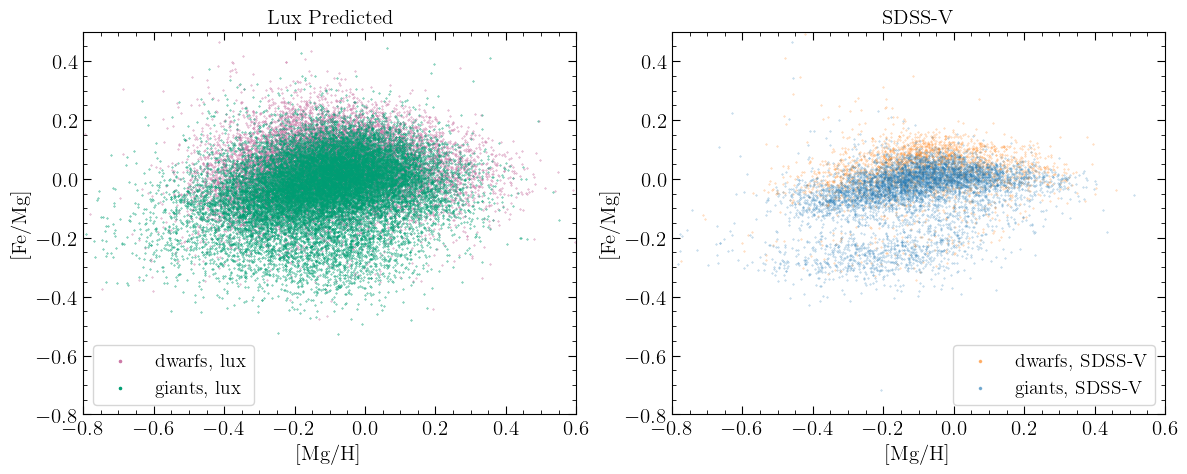

In [7]:
giants_color_sdss = 'tab:blue'
dwarfs_color_sdss = 'tab:orange'

giants_color_lux = '#009E73'  # Bluish Green
dwarfs_color_lux = '#CC79A7'  # Reddish Purple


plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(lux_pred_dwarfs['mg_h'], lux_pred_dwarfs['fe_mg'], s = 0.1, label = 'dwarfs, lux', color = dwarfs_color_lux)
plt.scatter(lux_pred_giants['mg_h'], lux_pred_giants['fe_mg'], s = 0.1, label = 'giants, lux', color = giants_color_lux)
plt.legend(markerscale=5)
plt.ylim(-0.8,0.5)
plt.xlim(-0.8,0.6)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.title("Lux Predicted")


plt.subplot(1,2,2)
plt.scatter(training_dwarfs_sdss['mg_h'], training_dwarfs_sdss['fe_mg'], s = 0.1, label = 'dwarfs, SDSS-V', alpha = 0.5, color = dwarfs_color_sdss)
plt.scatter(training_giants_sdss['mg_h'], training_giants_sdss['fe_mg'], s = 0.1, label = 'giants, SDSS-V', alpha = 0.5, color = giants_color_sdss)
plt.legend(markerscale=5)
plt.ylim(-0.8,0.5)
plt.xlim(-0.8,0.6)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.title("SDSS-V")


plt.tight_layout()

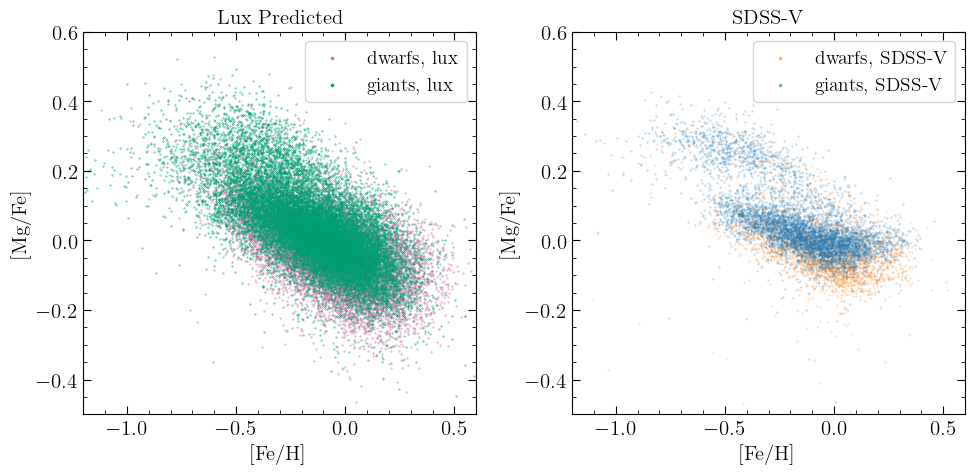

In [8]:
giants_color_sdss = 'tab:blue'
dwarfs_color_sdss = 'tab:orange'

giants_color_lux = '#009E73'  # Bluish Green
dwarfs_color_lux = '#CC79A7'  # Reddish Purple

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(lux_pred_dwarfs['fe_h'], lux_pred_dwarfs['mg_fe'], s = 0.1, label = 'dwarfs, lux', color = dwarfs_color_lux)
plt.scatter(lux_pred_giants['fe_h'], lux_pred_giants['mg_fe'], s = 0.1, label = 'giants, lux', color = giants_color_lux)
plt.legend(markerscale=5)
plt.xlim(-1.2, 0.6)
plt.ylim(-0.5, 0.6)
plt.xlabel('[Fe/H]')
plt.ylabel('[Mg/Fe]')
plt.title("Lux Predicted")


plt.subplot(1,2,2)
plt.scatter(training_dwarfs_sdss['fe_h'], training_dwarfs_sdss['mg_fe'], s = 0.1, label = 'dwarfs, SDSS-V', alpha = 0.5, color = dwarfs_color_sdss)
plt.scatter(training_giants_sdss['fe_h'], training_giants_sdss['mg_fe'], s = 0.1, label = 'giants, SDSS-V', alpha = 0.5, color = giants_color_sdss)
plt.legend(markerscale=5)
plt.xlim(-1.2, 0.6)
plt.ylim(-0.5, 0.6)
plt.xlabel('[Fe/H]')
plt.ylabel('[Mg/Fe]')
plt.title("SDSS-V")


plt.tight_layout()

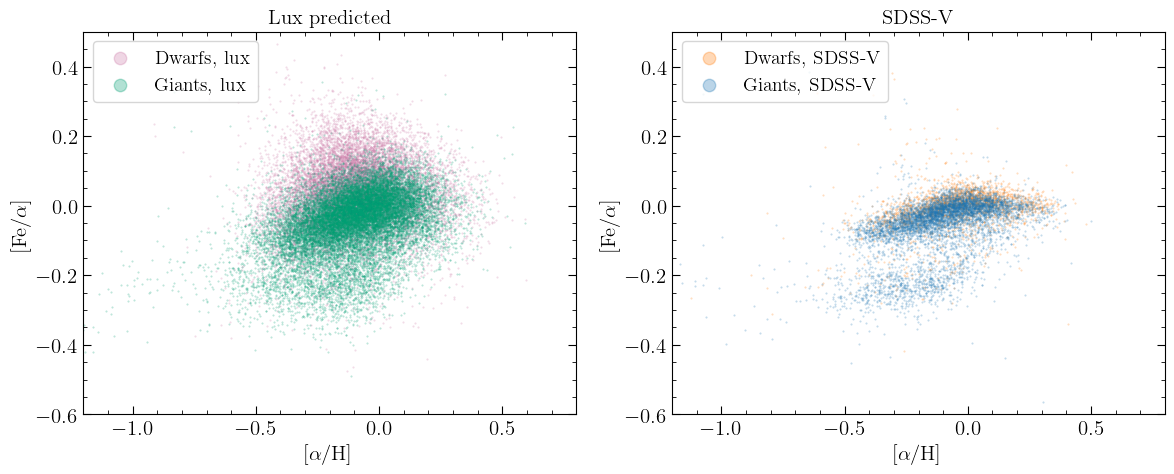

In [9]:
giants_color_sdss = 'tab:blue'
dwarfs_color_sdss = 'tab:orange'

giants_color_lux = '#009E73'  # Bluish Green
dwarfs_color_lux = '#CC79A7'  # Reddish Purple

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(lux_pred_dwarfs['mg_h'], lux_pred_dwarfs['fe_mg'], s = 0.2, label = 'Dwarfs, lux', color = dwarfs_color_lux, alpha = 0.3)
plt.scatter(lux_pred_giants['alpha_h'], lux_pred_giants['fe_alpha'], s = 0.2, label = 'Giants, lux', color = giants_color_lux, alpha = 0.3)
plt.legend(markerscale=20, loc = 'upper left')
plt.ylim(-0.6,0.5)
plt.xlim(-1.2, 0.8)
plt.xlabel(r'[$\alpha$/H]')
plt.ylabel(r'[Fe/$\alpha$]')
plt.title("Lux predicted")


plt.subplot(1,2,2)
plt.scatter(training_dwarfs_sdss['alpha_h'], training_dwarfs_sdss['fe_alpha'], s = 0.2, label = 'Dwarfs, SDSS-V', alpha = 0.3, color = dwarfs_color_sdss)
plt.scatter(training_giants_sdss['alpha_h'], training_giants_sdss['fe_alpha'], s = 0.2, label = 'Giants, SDSS-V', alpha = 0.3, color = giants_color_sdss)
plt.legend(markerscale=20, loc = 'upper left')
plt.ylim(-0.6,0.5)
plt.xlim(-1.2, 0.8)
plt.xlabel(r'[$\alpha$/H]')
plt.ylabel(r'[Fe/$\alpha$]')
plt.title("SDSS-V")



plt.savefig('plots/giants_and_dwarfs_fe_alpha_alpha_H.pdf', format='pdf', bbox_inches='tight', dpi=200)
plt.tight_layout()

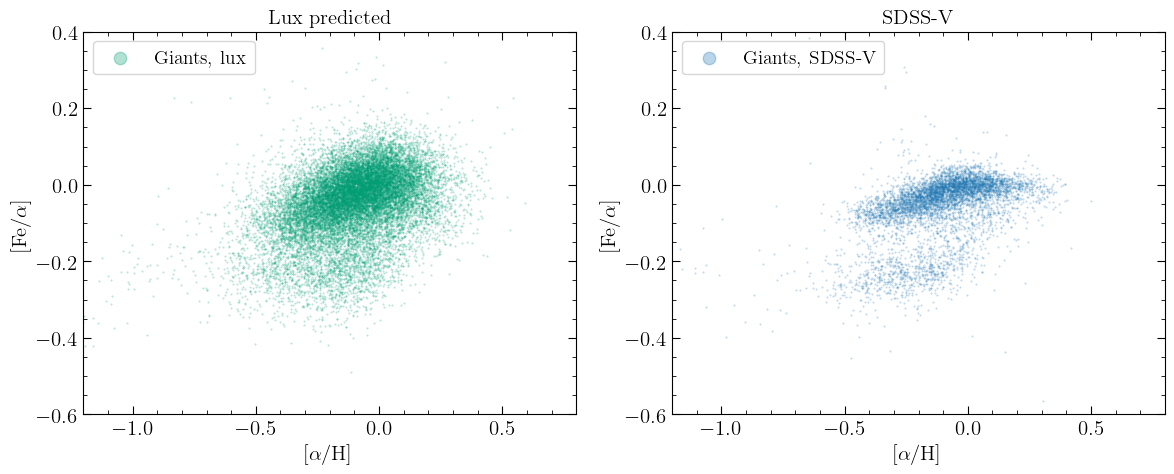

In [10]:
giants_color_sdss = 'tab:blue'
dwarfs_color_sdss = 'tab:orange'

giants_color_lux = '#009E73'  # Bluish Green
dwarfs_color_lux = '#CC79A7'  # Reddish Purple

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
#plt.scatter(lux_pred_dwarfs['mg_h'], lux_pred_dwarfs['fe_mg'], s = 0.2, label = 'Dwarfs, lux', color = dwarfs_color_lux, alpha = 0.3)
plt.scatter(lux_pred_giants['alpha_h'], lux_pred_giants['fe_alpha'], s = 0.2, label = 'Giants, lux', color = giants_color_lux, alpha = 0.3)
plt.legend(markerscale=20, loc = 'upper left')
plt.ylim(-0.6,0.4)
plt.xlim(-1.2, 0.8)
plt.xlabel(r'[$\alpha$/H]')
plt.ylabel(r'[Fe/$\alpha$]')
plt.title("Lux predicted")


plt.subplot(1,2,2)
#plt.scatter(training_dwarfs_sdss['alpha_h'], training_dwarfs_sdss['fe_alpha'], s = 0.2, label = 'Dwarfs, SDSS-V', alpha = 0.3, color = dwarfs_color_sdss)
plt.scatter(training_giants_sdss['alpha_h'], training_giants_sdss['fe_alpha'], s = 0.2, label = 'Giants, SDSS-V', alpha = 0.3, color = giants_color_sdss)
plt.legend(markerscale=20, loc = 'upper left')
plt.ylim(-0.6,0.4)
plt.xlim(-1.2, 0.8)
plt.xlabel(r'[$\alpha$/H]')
plt.ylabel(r'[Fe/$\alpha$]')
plt.title("SDSS-V")

plt.savefig('plots/giants_fe_alpha_alpha_H.pdf', format='pdf', bbox_inches='tight', dpi=200)
plt.tight_layout()

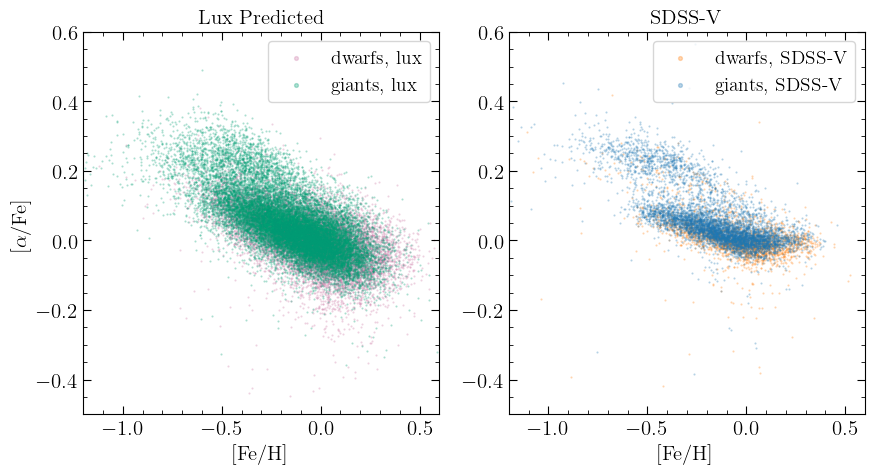

In [11]:
giants_color_sdss = 'tab:blue'
dwarfs_color_sdss = 'tab:orange'

giants_color_lux = '#009E73'  # Bluish Green
dwarfs_color_lux = '#CC79A7'  # Reddish Purple

plt.figure(figsize=(9,5))
plt.subplot(1,2,1)
plt.scatter(lux_pred_dwarfs['fe_h'], lux_pred_dwarfs['alpha_fe'], s = 0.3, label = 'dwarfs, lux', color = dwarfs_color_lux, alpha = 0.3)
plt.scatter(lux_pred_giants['fe_h'], lux_pred_giants['alpha_fe'], s = 0.3, label = 'giants, lux', color = giants_color_lux, alpha = 0.3)
plt.legend(markerscale=5)
plt.xlim(-1.2, 0.6)
plt.ylim(-0.5, 0.6)
plt.xlabel('[Fe/H]')
plt.ylabel(r'[$\alpha$/Fe]')
plt.title("Lux Predicted")


plt.subplot(1,2,2)
plt.scatter(training_dwarfs_sdss['fe_h'], training_dwarfs_sdss['alpha_fe'], s = 0.3, label = 'dwarfs, SDSS-V', alpha = 0.3, color = dwarfs_color_sdss)
plt.scatter(training_giants_sdss['fe_h'], training_giants_sdss['alpha_fe'], s = 0.3, label = 'giants, SDSS-V', alpha = 0.3, color = giants_color_sdss)
plt.legend(markerscale=5)
plt.xlim(-1.2, 0.6)
plt.ylim(-0.5, 0.6)
plt.xlabel('[Fe/H]')
#plt.ylabel(r'[$\alpha$/Fe]')
plt.title("SDSS-V")


plt.tight_layout()
plt.savefig('plots/alpha_fe.pdf', format='pdf', bbox_inches='tight', dpi=200)

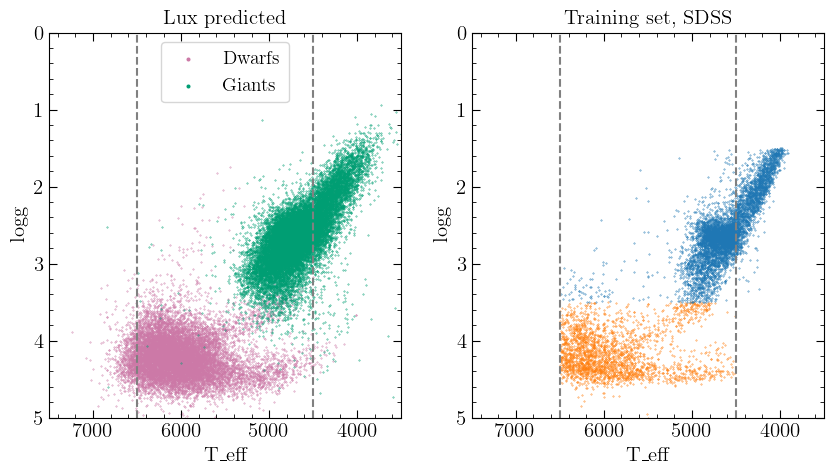

In [12]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Lux predicted")
plt.scatter(lux_pred_dwarfs['teff'], lux_pred_dwarfs['logg'], s = 0.1, label = 'Dwarfs', color = dwarfs_color_lux)
plt.scatter(lux_pred_giants['teff'], lux_pred_giants['logg'], s = 0.1, label = 'Giants', color = giants_color_lux)
plt.axvline(4500, linestyle='--', color = 'gray')
plt.axvline(6500, linestyle='--', color = 'gray')
plt.legend(markerscale=6)
plt.xlim(3500,7500)
plt.xlabel("T_eff")
plt.ylabel("logg")
plt.ylim(0,5)
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()


plt.subplot(1,2,2)
plt.title("Training set, SDSS")
plt.scatter(training_dwarfs_sdss['teff'], training_dwarfs_sdss['logg'], s = 0.1, label = 'Dwarfs', color = dwarfs_color_sdss)
plt.scatter(training_giants_sdss['teff'], training_giants_sdss['logg'], s = 0.1, label = 'Giants', color = giants_color_sdss)
plt.axvline(4500, linestyle='--', color = 'gray')
plt.axvline(6500, linestyle='--', color = 'gray')
plt.xlim(3500,7500)
plt.xlabel("T_eff")
plt.ylabel("logg")
plt.ylim(0,5)
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

Text(0.5, 0.98, 'SDSS training set, giants')

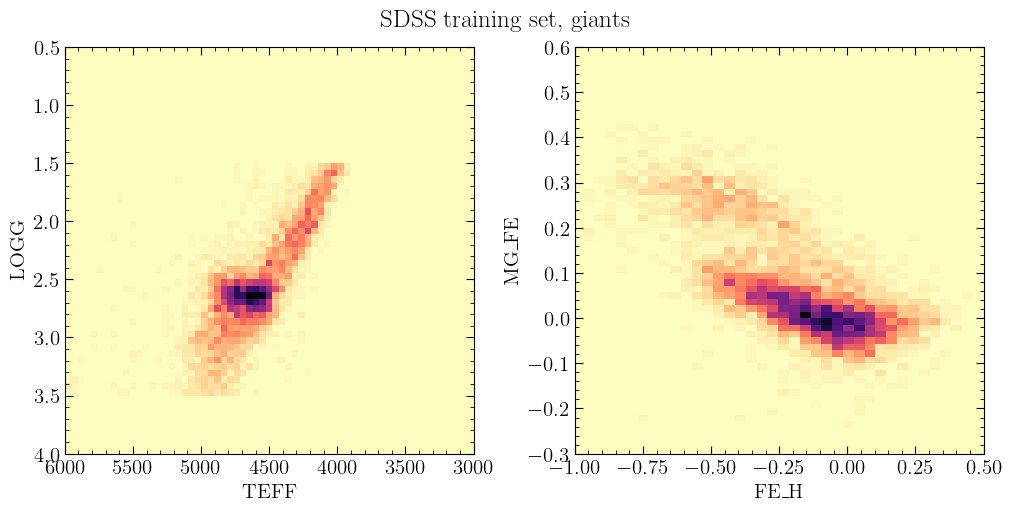

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), layout="constrained")

axes[0].hist2d(
    training_giants_sdss["teff"],
    training_giants_sdss["logg"],
    bins=(np.linspace(3000, 6000, 64), np.linspace(0.5, 4.0, 64)),
    cmap="magma_r",
)
axes[0].set(xlim=(6000, 3000), ylim=(4.0, 0.5), xlabel="TEFF", ylabel="LOGG")

axes[1].hist2d(
    training_giants_sdss["fe_h"],
    training_giants_sdss["mg_fe"],
    bins=(np.linspace(-2.0, 0.5, 64), np.linspace(-0.3, 0.6, 64)),
    cmap="magma_r",
)
axes[1].set(xlim=(-1.0, 0.5), ylim=(-0.3, 0.6), xlabel="FE_H", ylabel="MG_FE")

plt.suptitle("SDSS training set, giants")

Text(0.5, 0.98, 'SDSS training set, giants')

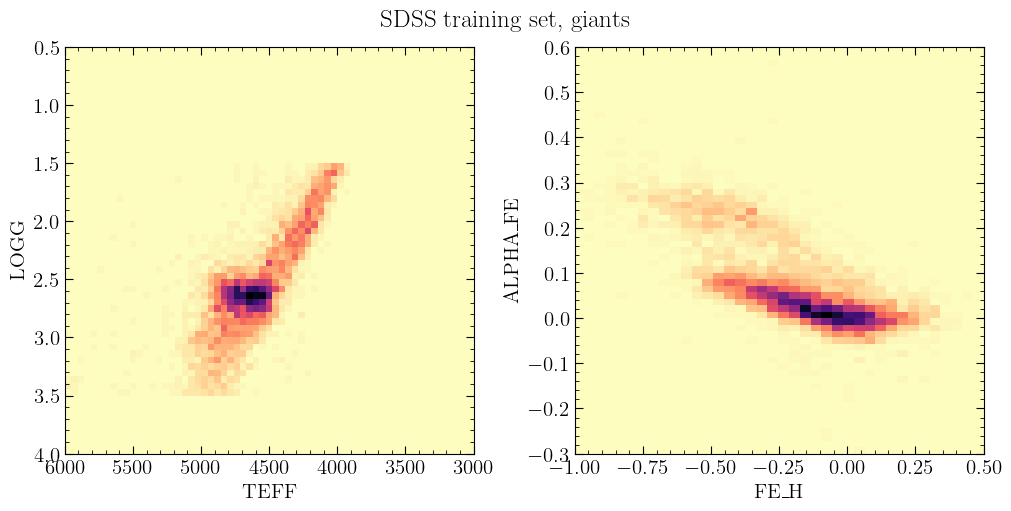

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), layout="constrained")

axes[0].hist2d(
    training_giants_sdss["teff"],
    training_giants_sdss["logg"],
    bins=(np.linspace(3000, 6000, 64), np.linspace(0.5, 4.0, 64)),
    cmap="magma_r",
)
axes[0].set(xlim=(6000, 3000), ylim=(4.0, 0.5), xlabel="TEFF", ylabel="LOGG")

axes[1].hist2d(
    training_giants_sdss["fe_h"],
    training_giants_sdss["alpha_fe"],
    bins=(np.linspace(-2.0, 0.5, 64), np.linspace(-0.3, 0.6, 64)),
    cmap="magma_r",
)
axes[1].set(xlim=(-1.0, 0.5), ylim=(-0.3, 0.6), xlabel="FE_H", ylabel="ALPHA_FE")

plt.suptitle("SDSS training set, giants")

Text(0.5, 0.98, 'Lux predicted, giants')

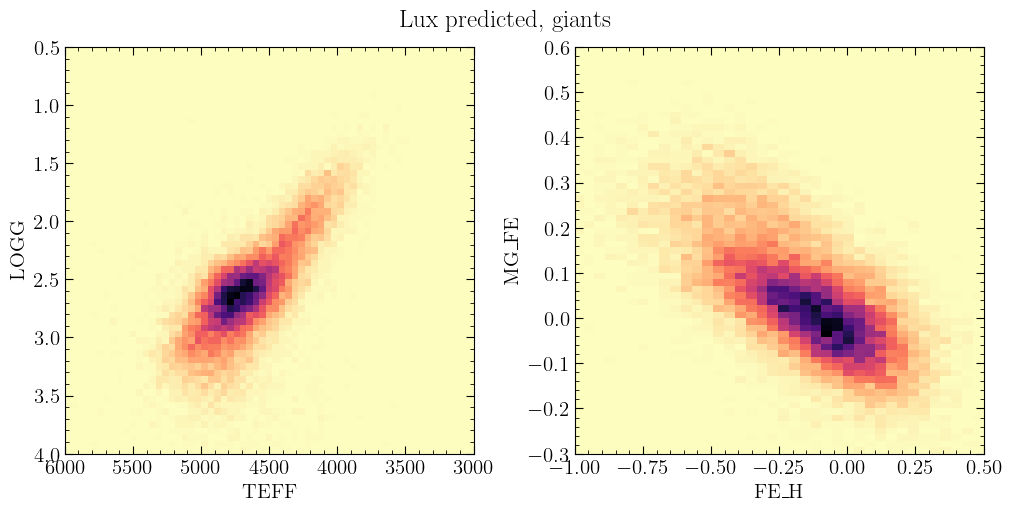

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), layout="constrained")

axes[0].hist2d(
    lux_pred_giants["teff"],
    lux_pred_giants["logg"],
    bins=(np.linspace(3000, 6000, 64), np.linspace(0.5, 4.0, 64)),
    cmap="magma_r",
)
axes[0].set(xlim=(6000, 3000), ylim=(4.0, 0.5), xlabel="TEFF", ylabel="LOGG")

axes[1].hist2d(
    lux_pred_giants["fe_h"],
    lux_pred_giants["mg_fe"],
    bins=(np.linspace(-2.0, 0.5, 64), np.linspace(-0.3, 0.6, 64)),
    cmap="magma_r",
)
axes[1].set(xlim=(-1.0, 0.5), ylim=(-0.3, 0.6), xlabel="FE_H", ylabel="MG_FE")

plt.suptitle("Lux predicted, giants")

Text(0.5, 0.98, 'Lux predicted, giants')

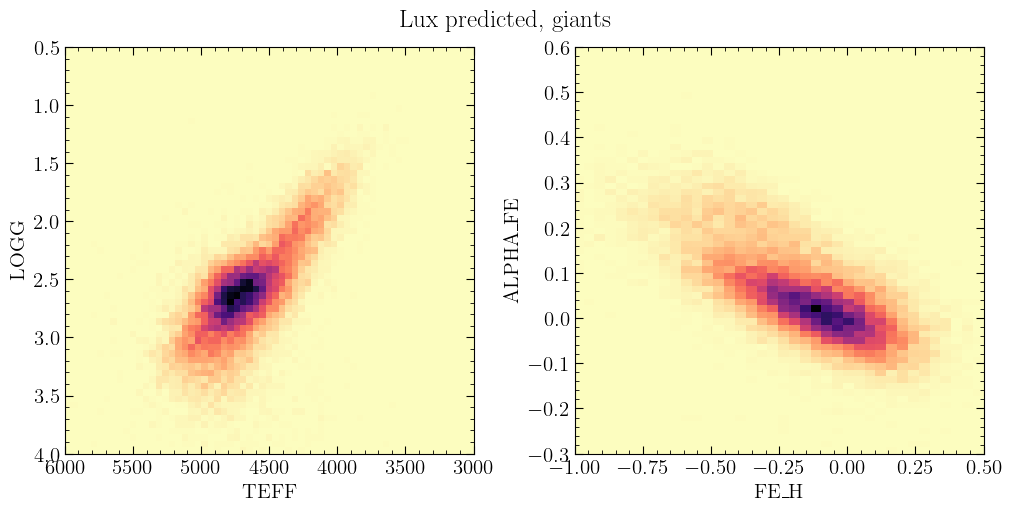

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), layout="constrained")

axes[0].hist2d(
    lux_pred_giants["teff"],
    lux_pred_giants["logg"],
    bins=(np.linspace(3000, 6000, 64), np.linspace(0.5, 4.0, 64)),
    cmap="magma_r",
)
axes[0].set(xlim=(6000, 3000), ylim=(4.0, 0.5), xlabel="TEFF", ylabel="LOGG")

axes[1].hist2d(
    lux_pred_giants["fe_h"],
    lux_pred_giants["alpha_fe"],
    bins=(np.linspace(-2.0, 0.5, 64), np.linspace(-0.3, 0.6, 64)),
    cmap="magma_r",
)
axes[1].set(xlim=(-1.0, 0.5), ylim=(-0.3, 0.6), xlabel="FE_H", ylabel="ALPHA_FE")

plt.suptitle("Lux predicted, giants")

Text(0.5, 0.98, 'SDSS training set, giants')

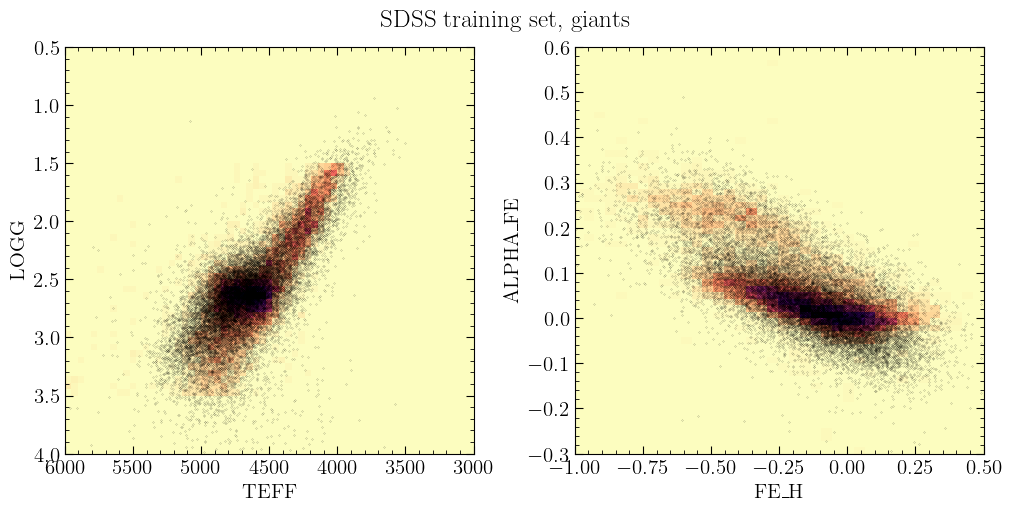

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), layout="constrained")

axes[0].hist2d(
    training_giants_sdss["teff"],
    training_giants_sdss["logg"],
    bins=(np.linspace(3000, 6000, 64), np.linspace(0.5, 4.0, 64)),
    cmap="magma_r",
)
axes[0].scatter(lux_pred_giants['teff'], lux_pred_giants['logg'], s = 0.01, color = 'black')
axes[0].set(xlim=(6000, 3000), ylim=(4.0, 0.5), xlabel="TEFF", ylabel="LOGG")

axes[1].hist2d(
    training_giants_sdss["fe_h"],
    training_giants_sdss["alpha_fe"],
    bins=(np.linspace(-2.0, 0.5, 64), np.linspace(-0.3, 0.6, 64)),
    cmap="magma_r",
)
axes[1].scatter(lux_pred_giants['fe_h'], lux_pred_giants['alpha_fe'], s = 0.01, color = 'black')
axes[1].set(xlim=(-1.0, 0.5), ylim=(-0.3, 0.6), xlabel="FE_H", ylabel="ALPHA_FE")

plt.suptitle("SDSS training set, giants")

Text(0.5, 0.98, 'SDSS training set, giants + dwarfs')

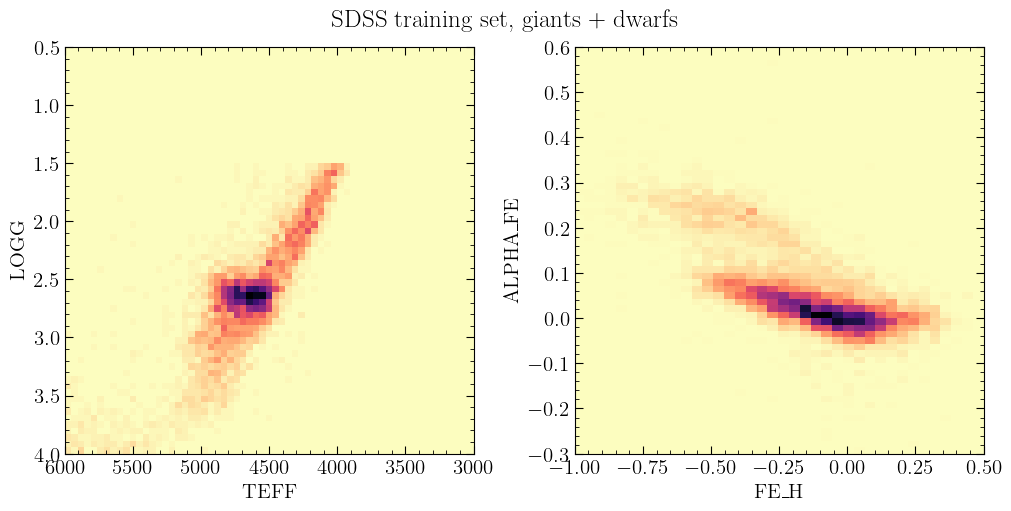

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), layout="constrained")

axes[0].hist2d(
    training_sdss_all["teff"],
    training_sdss_all["logg"],
    bins=(np.linspace(3000, 6000, 64), np.linspace(0.5, 4.0, 64)),
    cmap="magma_r",
)
axes[0].set(xlim=(6000, 3000), ylim=(4.0, 0.5), xlabel="TEFF", ylabel="LOGG")

axes[1].hist2d(
    training_sdss_all["fe_h"],
    training_sdss_all["alpha_fe"],
    bins=(np.linspace(-2.0, 0.5, 64), np.linspace(-0.3, 0.6, 64)),
    cmap="magma_r",
)
axes[1].set(xlim=(-1.0, 0.5), ylim=(-0.3, 0.6), xlabel="FE_H", ylabel="ALPHA_FE")

plt.suptitle("SDSS training set, giants + dwarfs")

Text(0.5, 0.98, 'Lux predicted, giants + dwarfs')

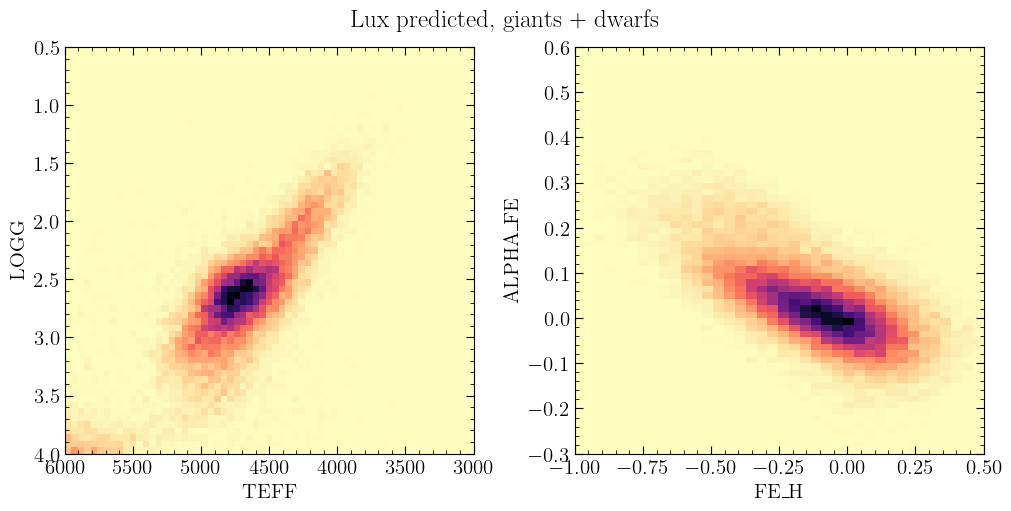

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), layout="constrained")

axes[0].hist2d(
    lux_pred_all["teff"],
    lux_pred_all["logg"],
    bins=(np.linspace(3000, 6000, 64), np.linspace(0.5, 4.0, 64)),
    cmap="magma_r",
)
axes[0].set(xlim=(6000, 3000), ylim=(4.0, 0.5), xlabel="TEFF", ylabel="LOGG")

axes[1].hist2d(
    lux_pred_all["fe_h"],
    lux_pred_all["alpha_fe"],
    bins=(np.linspace(-2.0, 0.5, 64), np.linspace(-0.3, 0.6, 64)),
    cmap="magma_r",
)
axes[1].set(xlim=(-1.0, 0.5), ylim=(-0.3, 0.6), xlabel="FE_H", ylabel="ALPHA_FE")

plt.suptitle("Lux predicted, giants + dwarfs")

In [20]:
gaia_with_loc = pd.read_csv("data/gaia_df_with_r_and_zmax.csv")

gaia_with_loc.columns

Index(['source_id', 'ra', 'dec', 'parallax', 'pmra', 'pmdec',
       'radial_velocity', 'rvs_spec_sig_to_noise', 'teff_gspphot',
       'logg_gspphot', 'mh_gspphot', 'phot_g_mean_mag', 'phot_rp_mean_mag',
       'zmax_med', 'r_gal'],
      dtype='object')

In [21]:
# 1. Subset the Gaia results to just the ID and the two new columns
gaia_subset = gaia_with_loc[['source_id', 'zmax_med', 'r_gal']]

# 2. Add the columns to lux_pred_all (how='left' keeps all your existing rows)
lux_pred_all = lux_pred_all.merge(gaia_subset, on='source_id', how='left')

# 3. Add the columns to training_sdss_all
training_sdss_all = training_sdss_all.merge(gaia_subset, on='source_id', how='left')

In [22]:
training_sdss_all['r_gal']

0       9.885117
1       9.396706
2       9.152125
3       9.813566
4       8.910574
          ...   
8479    8.145800
8480    8.126784
8481    8.147560
8482    8.052161
8483    8.093814
Name: r_gal, Length: 8484, dtype: float64

In [23]:
np.max(training_sdss_all['r_gal'])

np.float64(12.000171)

In [24]:
np.max(training_sdss_all['zmax_med'])

np.float64(13.579614)

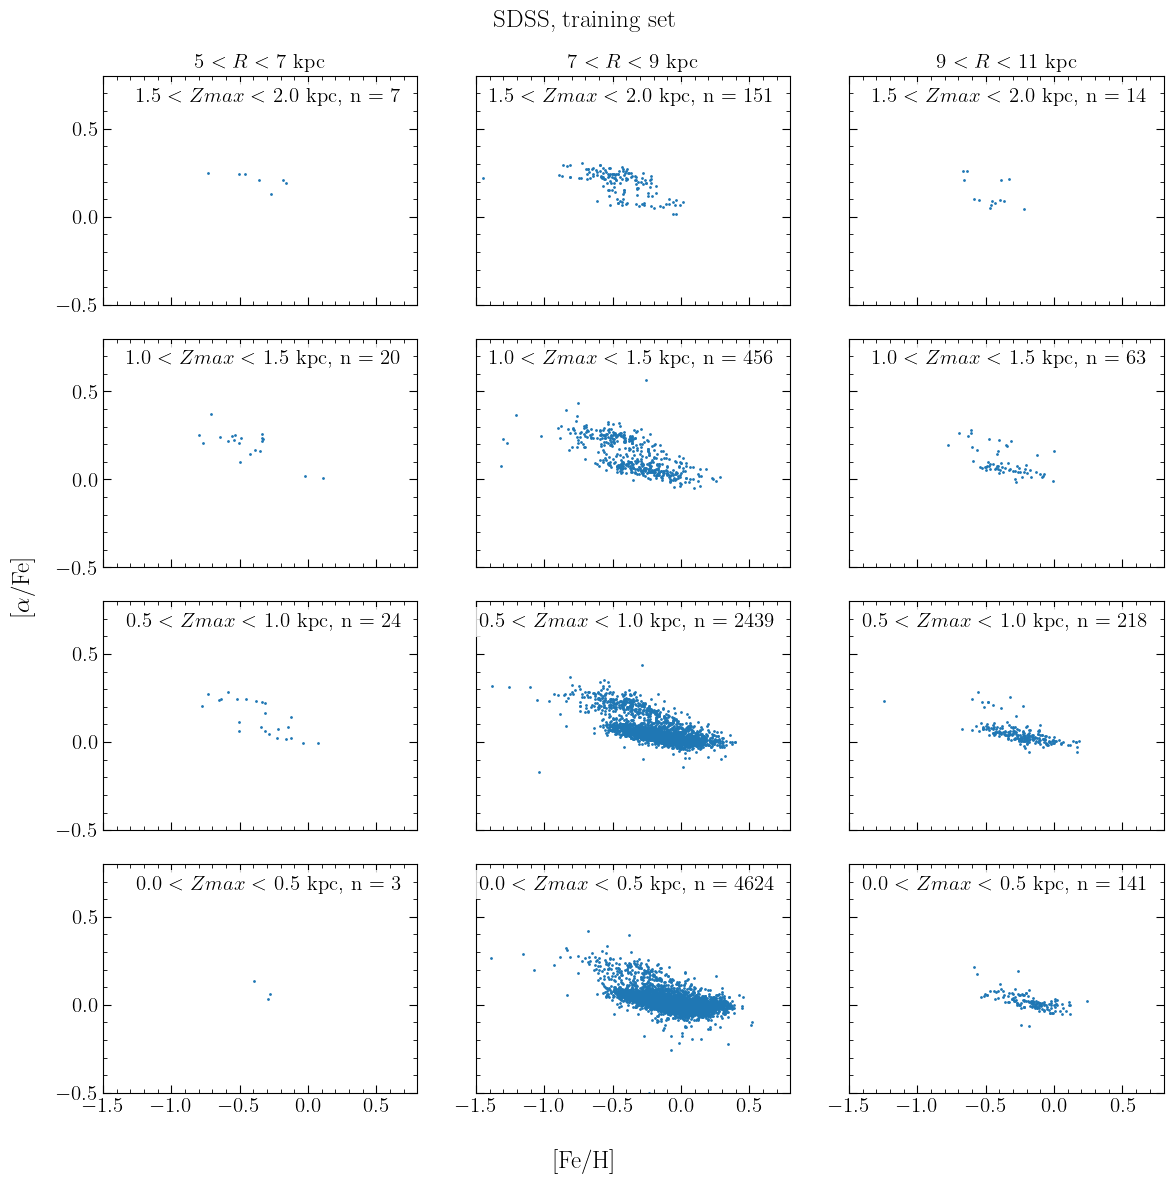

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the bins
r_bins = np.arange(5, 13, 2)            # [0, 4, 8, 12, 16]
z_bins = np.arange(0, 2.5, 0.5)    # [0.0, 0.5, 1.0, 1.5, 2.0]

n_rows = len(z_bins) - 1
n_cols = len(r_bins) - 1

# 2. Set up the matplotlib grid
fig, axes = plt.subplots(
    nrows=n_rows, 
    ncols=n_cols, 
    figsize=(12, 12), 
    sharex=True, 
    sharey=True
)

# 3. Iterate and plot
for i in range(n_rows):
    # Invert row index so Z=0 is at the bottom
    row_idx = n_rows - 1 - i 
    z_min, z_max = z_bins[i], z_bins[i+1]
    
    for j in range(n_cols):
        r_min, r_max = r_bins[j], r_bins[j+1]
        ax = axes[row_idx, j]
        
        # Filter the dataset
        mask = (
            (training_sdss_all['r_gal'] >= r_min) & 
            (training_sdss_all['r_gal'] < r_max) & 
            (training_sdss_all['zmax_med'] >= z_min) & 
            (training_sdss_all['zmax_med'] < z_max)
        )
        subset = training_sdss_all[mask]
        
        # Scatter plot for this bin
        ax.scatter(subset['fe_h'], subset['alpha_fe'], s=1, alpha=1, color='tab:blue')
        
        # Format grid titles (R bins on top row)
        if row_idx == 0:  
            ax.set_title(fr'{r_min} $ < R < $ {r_max} kpc')
            
        # Zmax text inside every plot (like a legend)
        ax.text(0.95, 0.95, fr'{z_min} $ < Zmax < $ {z_max} kpc,  n = {len(subset)}', 
                transform=ax.transAxes, 
                horizontalalignment='right', 
                verticalalignment='top',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        ax.set_ylim(-0.5, 0.8)
        ax.set_xlim(-1.5, 0.8)

# 4. Add global labels
fig.supxlabel('[Fe/H]')
fig.supylabel(r'[$\alpha$/Fe]')
fig.suptitle("SDSS, training set")
plt.tight_layout()
plt.show()

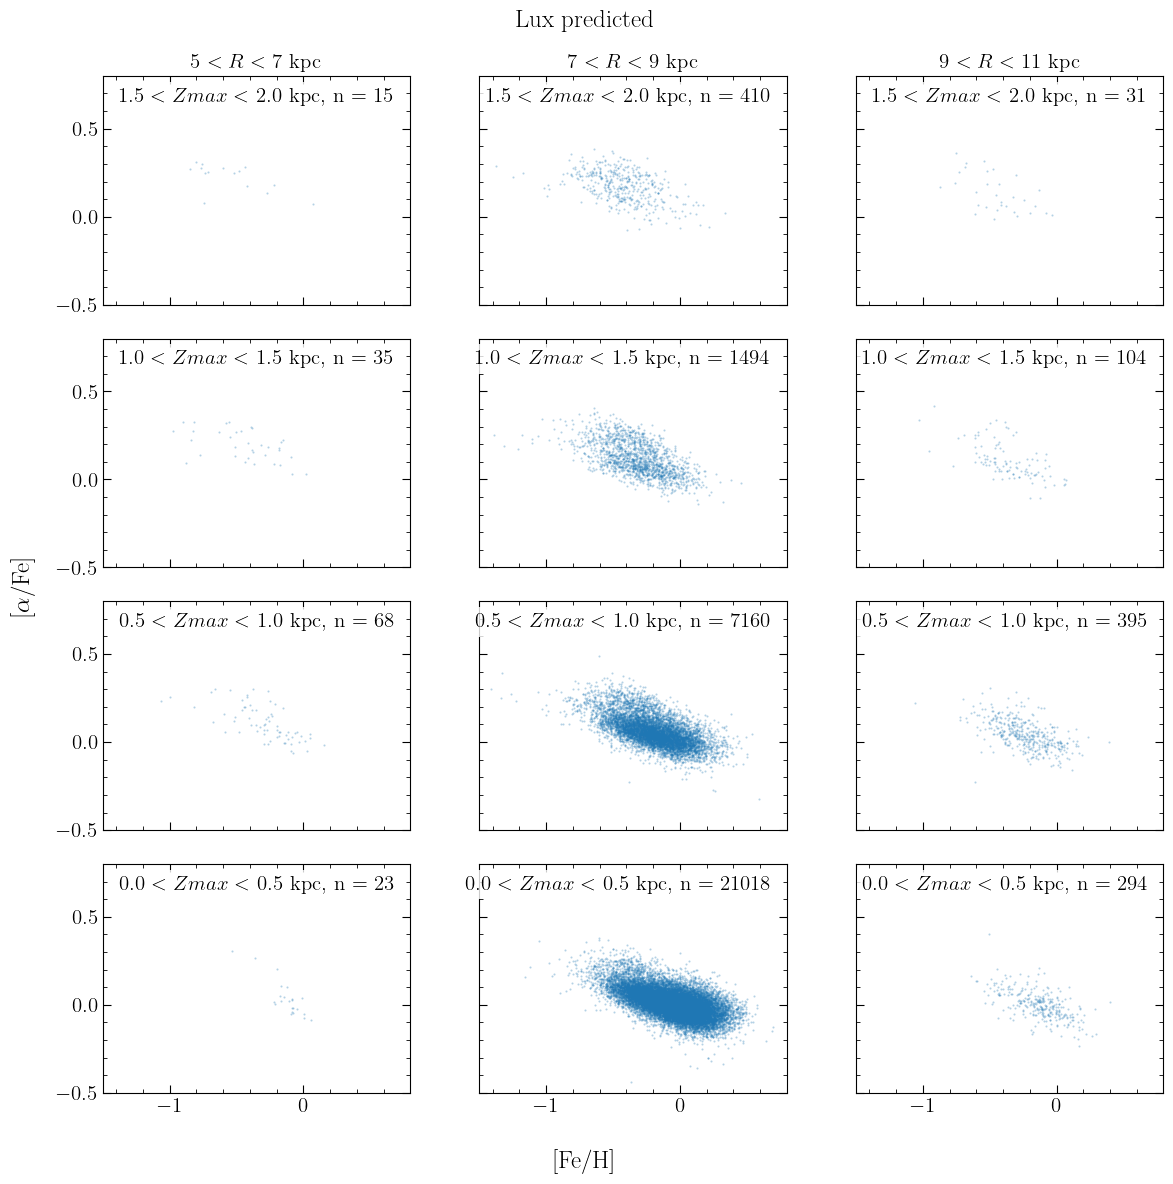

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the bins
r_bins = np.arange(5, 13, 2)            # [0, 4, 8, 12, 16]
z_bins = np.arange(0, 2.5, 0.5)    # [0.0, 0.5, 1.0, 1.5, 2.0]

n_rows = len(z_bins) - 1
n_cols = len(r_bins) - 1

# 2. Set up the matplotlib grid
fig, axes = plt.subplots(
    nrows=n_rows, 
    ncols=n_cols, 
    figsize=(12, 12), 
    sharex=True, 
    sharey=True
)

# 3. Iterate and plot
for i in range(n_rows):
    # Invert row index so Z=0 is at the bottom
    row_idx = n_rows - 1 - i 
    z_min, z_max = z_bins[i], z_bins[i+1]
    
    for j in range(n_cols):
        r_min, r_max = r_bins[j], r_bins[j+1]
        ax = axes[row_idx, j]
        
        # Filter the dataset
        mask = (
            (lux_pred_all['r_gal'] >= r_min) & 
            (lux_pred_all['r_gal'] < r_max) & 
            (lux_pred_all['zmax_med'] >= z_min) & 
            (lux_pred_all['zmax_med'] < z_max)
        )
        subset = lux_pred_all[mask]
        
        # Scatter plot for this bin
        ax.scatter(subset['fe_h'], subset['alpha_fe'], s=0.3, alpha=0.3, color='tab:blue')
        
        # Format grid titles (R bins on top row)
        if row_idx == 0:  
            ax.set_title(fr'{r_min} $ < R < $ {r_max} kpc')
            
        # Zmax text inside every plot (like a legend)
        ax.text(0.95, 0.95, fr'{z_min} $ < Zmax < $ {z_max} kpc, n = {len(subset)}', 
                transform=ax.transAxes, 
                horizontalalignment='right', 
                verticalalignment='top',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        ax.set_ylim(-0.5, 0.8)
        ax.set_xlim(-1.5, 0.8)

# 4. Add global labels
fig.supxlabel('[Fe/H]')
fig.supylabel(r'[$\alpha$/Fe]')
fig.suptitle("Lux predicted")
plt.tight_layout()
plt.show()

In [27]:
print("minimum r in lux_pred_all = ", min(lux_pred_all['r_gal']))
print("maximum r in lux_pred_all = ", max(lux_pred_all['r_gal']))


print("minimum r in training set = ", min(training_sdss_all['r_gal']))
print("maximum r in training set = ", max(training_sdss_all['r_gal']))

minimum r in lux_pred_all =  5.7772703
maximum r in lux_pred_all =  10.918427
minimum r in training set =  5.7772703
maximum r in training set =  12.000171


In [28]:
min(lux_pred_all['r_gal'])

5.7772703

In [29]:
max(lux_pred_all['r_gal'])

10.918427

In [30]:
np.arange(5, 13, 2) 

array([ 5,  7,  9, 11])

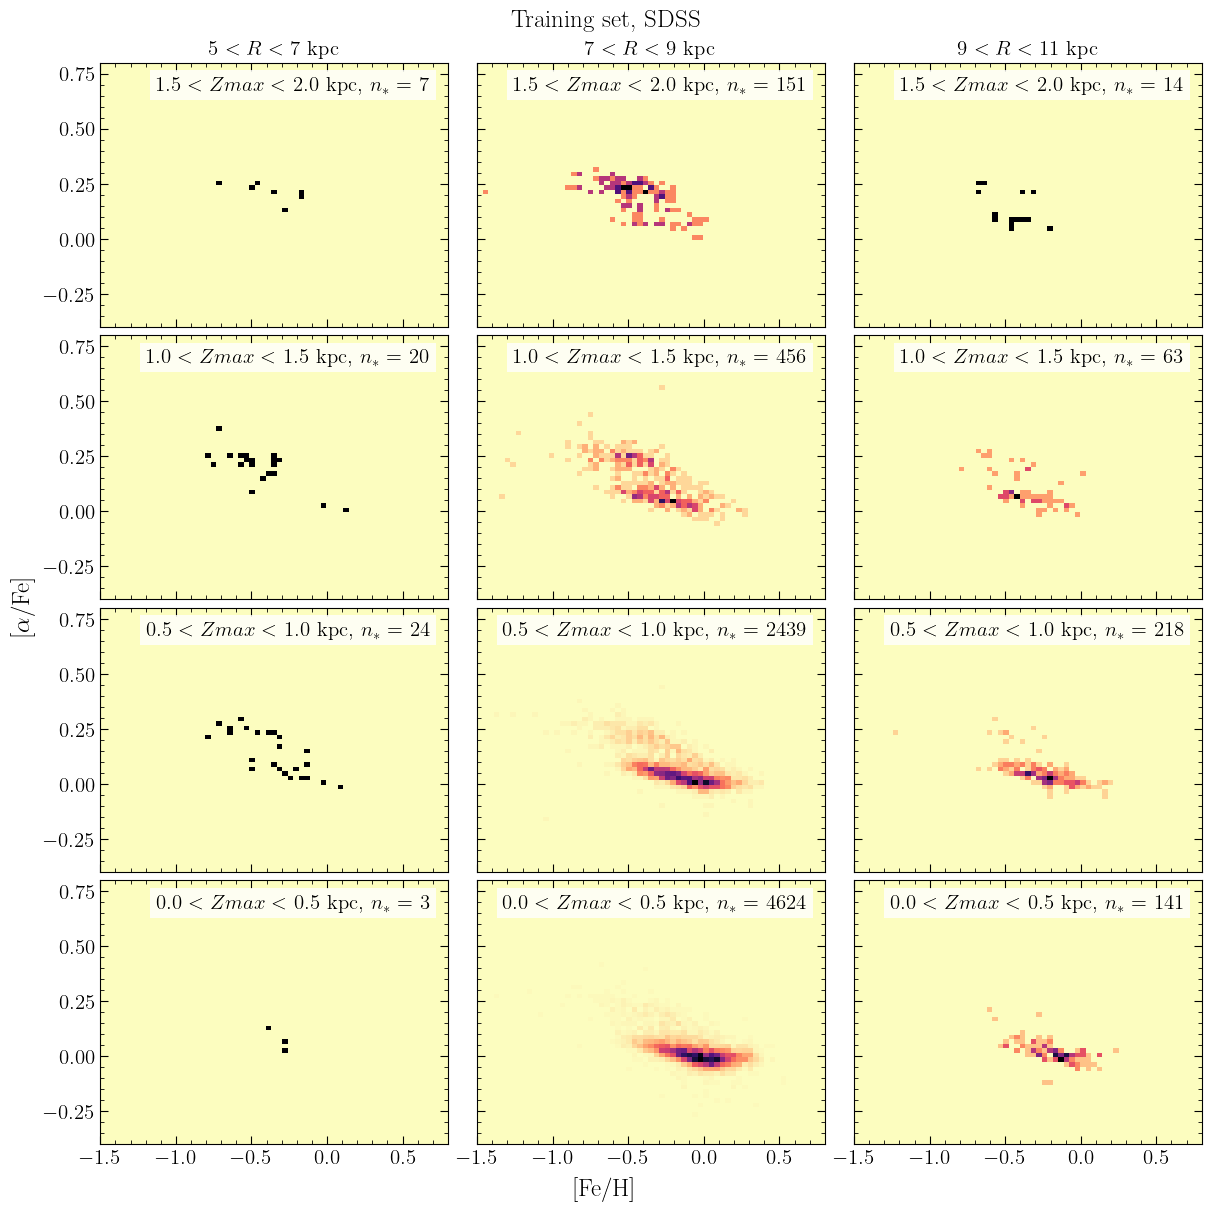

In [31]:
# 1. Define the spatial bins
r_bins = np.arange(5, 13, 2)       
z_bins = np.arange(0, 2.5, 0.5)    # [0.0, 0.5, 1.0, 1.5, 2.0]

n_rows = len(z_bins) - 1
n_cols = len(r_bins) - 1

# 2. Set up the matplotlib grid (using layout="constrained" from your first example)
fig, axes = plt.subplots(
    nrows=n_rows, 
    ncols=n_cols, 
    figsize=(12, 12), 
    sharex=True, 
    sharey=True,
    layout="constrained"
)

# Define 2D histogram bins to match your desired axis limits
feh_bins = np.linspace(-1.5, 0.8, 64)
alpha_bins = np.linspace(-0.5, 0.8, 64)

# 3. Iterate and plot
for i in range(n_rows):
    # Invert row index so Z=0 is at the bottom
    row_idx = n_rows - 1 - i 
    z_min, z_max = z_bins[i], z_bins[i+1]
    
    for j in range(n_cols):
        r_min, r_max = r_bins[j], r_bins[j+1]
        ax = axes[row_idx, j]
        
        # Filter the dataset
        mask = (
            (training_sdss_all['r_gal'] >= r_min) & 
            (training_sdss_all['r_gal'] < r_max) & 
            (training_sdss_all['zmax_med'] >= z_min) & 
            (training_sdss_all['zmax_med'] < z_max)
        )
        subset = training_sdss_all[mask]
        
        # 2D Histogram plot
        if len(subset) > 0: # Prevent errors if a bin has 0 stars
            ax.hist2d(
                subset['fe_h'], 
                subset['alpha_fe'], 
                bins=(feh_bins, alpha_bins), 
                cmap="magma_r",
            )
        
        # Format grid titles (R bins on top row)
        if row_idx == 0:  
            ax.set_title(fr'{r_min} $ < R < $ {r_max} kpc')
            
        # Zmax text inside every plot
        ax.text(0.95, 0.95, fr'{z_min} $ < Zmax < $ {z_max} kpc,  $n_*$ = {len(subset)}', 
                transform=ax.transAxes, 
                horizontalalignment='right', 
                verticalalignment='top',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        ax.set_ylim(-0.4, 0.8)
        ax.set_xlim(-1.5, 0.8)

# 4. Add global labels
fig.supxlabel('[Fe/H]')
fig.supylabel(r'[$\alpha$/Fe]')
fig.suptitle("Training set, SDSS")
plt.show()

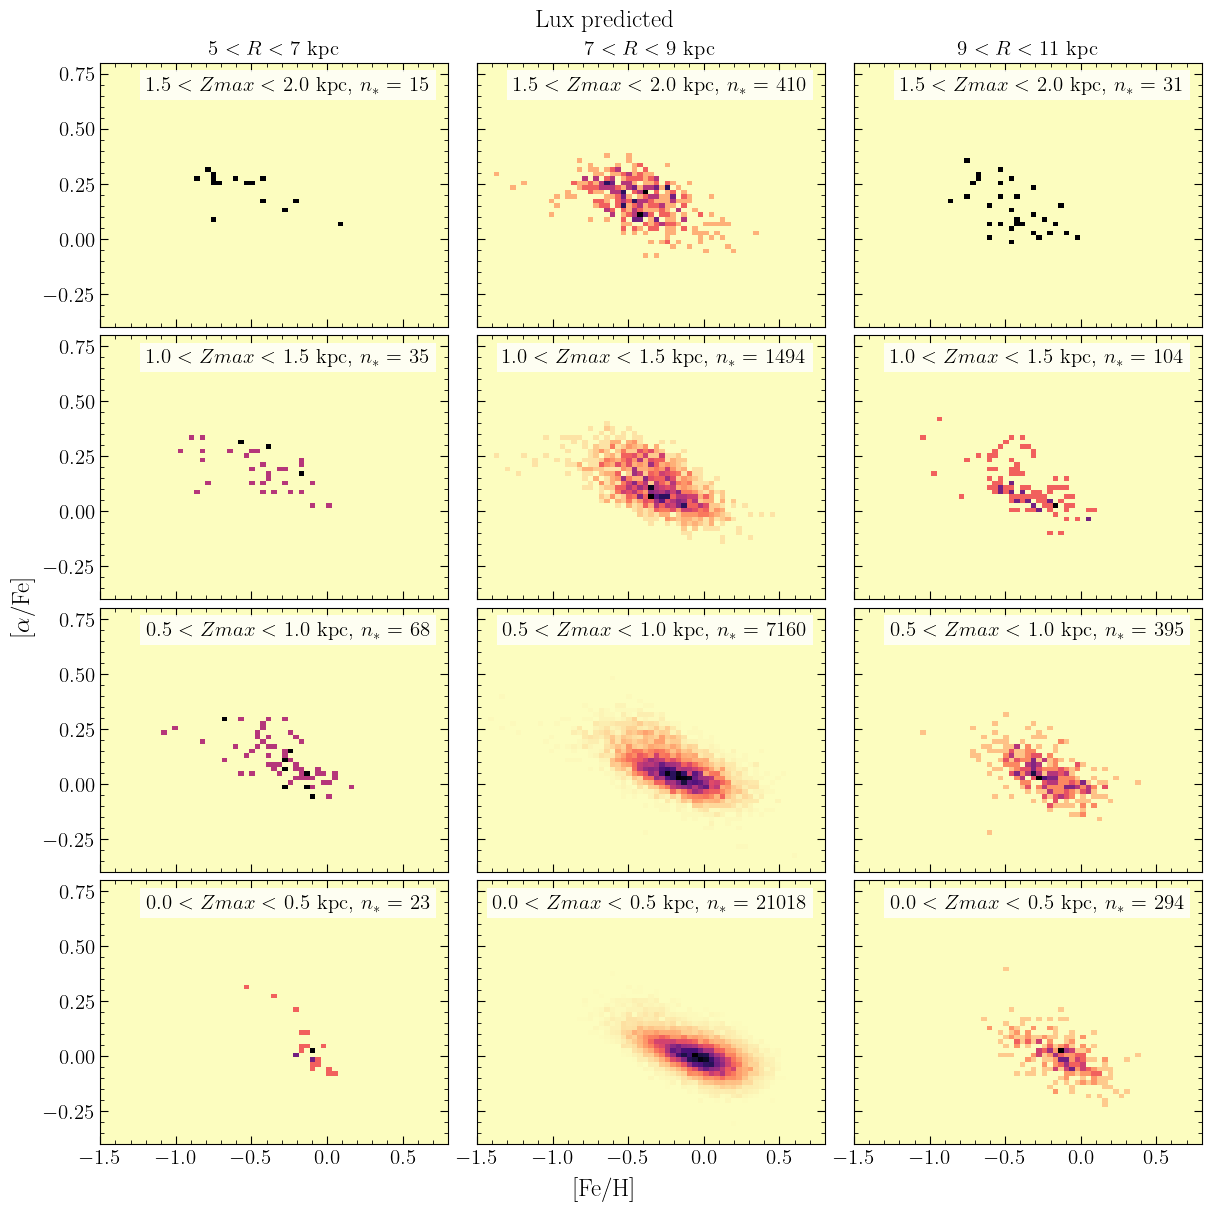

In [32]:
# 1. Define the spatial bins
r_bins = np.arange(5, 13, 2)       
z_bins = np.arange(0, 2.5, 0.5)    # [0.0, 0.5, 1.0, 1.5, 2.0]

n_rows = len(z_bins) - 1
n_cols = len(r_bins) - 1

# 2. Set up the matplotlib grid (using layout="constrained" from your first example)
fig, axes = plt.subplots(
    nrows=n_rows, 
    ncols=n_cols, 
    figsize=(12, 12), 
    sharex=True, 
    sharey=True,
    layout="constrained"
)

# Define 2D histogram bins to match your desired axis limits
feh_bins = np.linspace(-1.5, 0.8, 64)
alpha_bins = np.linspace(-0.5, 0.8, 64)

# 3. Iterate and plot
for i in range(n_rows):
    # Invert row index so Z=0 is at the bottom
    row_idx = n_rows - 1 - i 
    z_min, z_max = z_bins[i], z_bins[i+1]
    
    for j in range(n_cols):
        r_min, r_max = r_bins[j], r_bins[j+1]
        ax = axes[row_idx, j]
        
        # Filter the dataset
        mask = (
            (lux_pred_all['r_gal'] >= r_min) & 
            (lux_pred_all['r_gal'] < r_max) & 
            (lux_pred_all['zmax_med'] >= z_min) & 
            (lux_pred_all['zmax_med'] < z_max)
        )
        subset = lux_pred_all[mask]
        
        # 2D Histogram plot
        if len(subset) > 0: # Prevent errors if a bin has 0 stars
            ax.hist2d(
                subset['fe_h'], 
                subset['alpha_fe'], 
                bins=(feh_bins, alpha_bins), 
                cmap="magma_r",
            )
        
        # Format grid titles (R bins on top row)
        if row_idx == 0:  
            ax.set_title(fr'{r_min} $ < R < $ {r_max} kpc')
            
        # Zmax text inside every plot
        ax.text(0.95, 0.95, fr'{z_min} $ < Zmax < $ {z_max} kpc,  $n_*$ = {len(subset)}', 
                transform=ax.transAxes, 
                horizontalalignment='right', 
                verticalalignment='top',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        ax.set_ylim(-0.4, 0.8)
        ax.set_xlim(-1.5, 0.8)

# 4. Add global labels
fig.supxlabel('[Fe/H]')
fig.supylabel(r'[$\alpha$/Fe]')
fig.suptitle("Lux predicted")
plt.show()

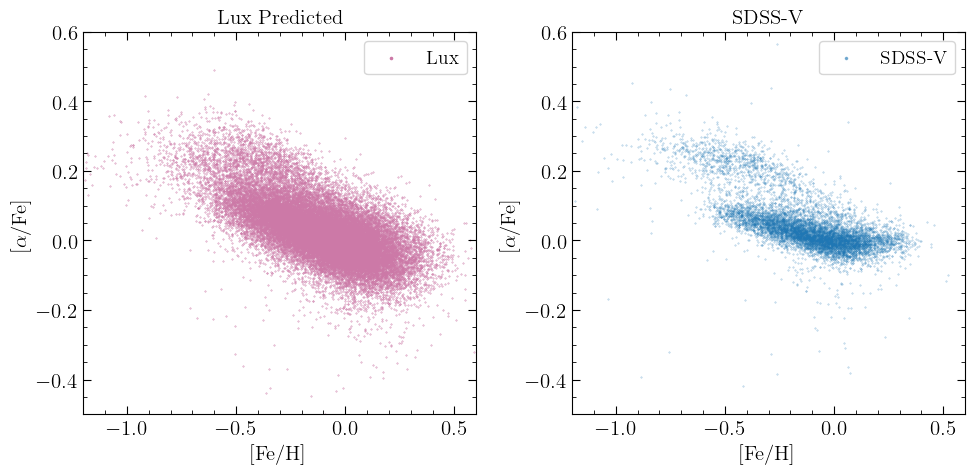

In [33]:
giants_color_sdss = 'tab:blue'
dwarfs_color_sdss = 'tab:orange'

giants_color_lux = '#009E73'  # Bluish Green
dwarfs_color_lux = '#CC79A7'  # Reddish Purple

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(lux_pred_all['fe_h'], lux_pred_all['alpha_fe'], s = 0.1, label = 'Lux', color = dwarfs_color_lux)
#plt.scatter(lux_pred_giants['fe_h'], lux_pred_giants['alpha_fe'], s = 0.1, label = 'giants, lux', color = giants_color_lux)
plt.legend(markerscale=5)
plt.xlim(-1.2, 0.6)
plt.ylim(-0.5, 0.6)
plt.xlabel('[Fe/H]')
plt.ylabel(r'[$\alpha$/Fe]')
plt.title("Lux Predicted")


plt.subplot(1,2,2)
#plt.scatter(training_dwarfs_sdss['fe_h'], training_dwarfs_sdss['alpha_fe'], s = 1, label = 'dwarfs, SDSS-V', alpha = 0.5, color = dwarfs_color_sdss)
plt.scatter(training_sdss_all['fe_h'], training_sdss_all['alpha_fe'], s = 0.1, label = 'SDSS-V', alpha = 0.5, color = giants_color_sdss)
plt.legend(markerscale=5)
plt.xlim(-1.2, 0.6)
plt.ylim(-0.5, 0.6)
plt.xlabel('[Fe/H]')
plt.ylabel(r'[$\alpha$/Fe]')
plt.title("SDSS-V")


plt.tight_layout()

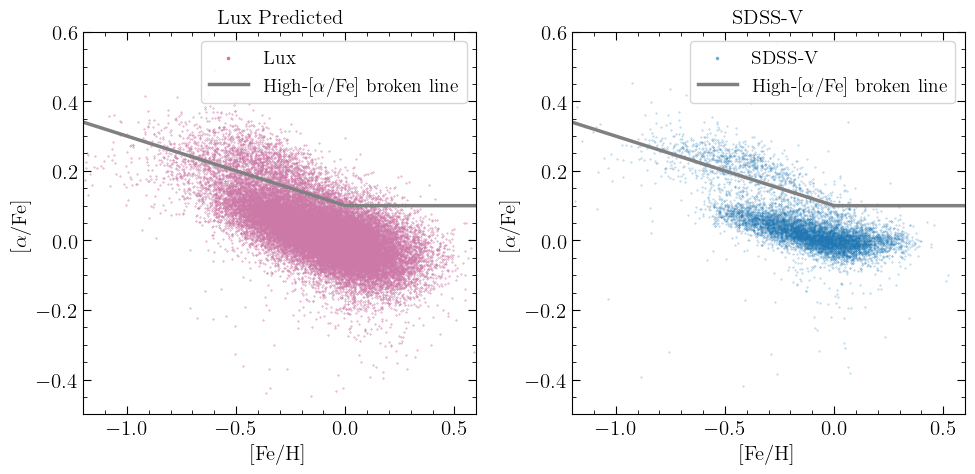

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Simplified broken line generation
# np.interp automatically flatlines outside the provided anchor points [-0.5, 0.2]
fe_h = np.linspace(-1.2, 0.6, 500)
alpha_fe = np.where(fe_h > 0, 0.10, 0.10 - 0.20 * fe_h)

# 2. Colors setup
giants_color_sdss = 'tab:blue'
dwarfs_color_sdss = 'tab:orange'
giants_color_lux = '#009E73'  # Bluish Green
dwarfs_color_lux = '#CC79A7'  # Reddish Purple

# 3. Plotting
plt.figure(figsize=(10, 5))

# Subplot 1: Lux
plt.subplot(1, 2, 1)
plt.scatter(lux_pred_all['fe_h'], lux_pred_all['alpha_fe'], s=0.1, label='Lux', color=dwarfs_color_lux)
plt.plot(fe_h, alpha_fe, color='gray', linewidth=2.5, label='High-[$\\alpha$/Fe] broken line')
plt.legend(markerscale=5)
plt.xlim(-1.2, 0.6)
plt.ylim(-0.5, 0.6)
plt.xlabel('[Fe/H]')
plt.ylabel(r'[$\alpha$/Fe]')
plt.title("Lux Predicted")

# Subplot 2: SDSS-V
plt.subplot(1, 2, 2)
plt.scatter(training_sdss_all['fe_h'], training_sdss_all['alpha_fe'], s=0.1, label='SDSS-V', alpha=0.5, color=giants_color_sdss)
plt.plot(fe_h, alpha_fe, color='gray', linewidth=2.5, label='High-[$\\alpha$/Fe] broken line')
plt.legend(markerscale=5)
plt.xlim(-1.2, 0.6)
plt.ylim(-0.5, 0.6)
plt.xlabel('[Fe/H]')
plt.ylabel(r'[$\alpha$/Fe]')
plt.title("SDSS-V")

plt.tight_layout()
plt.show()

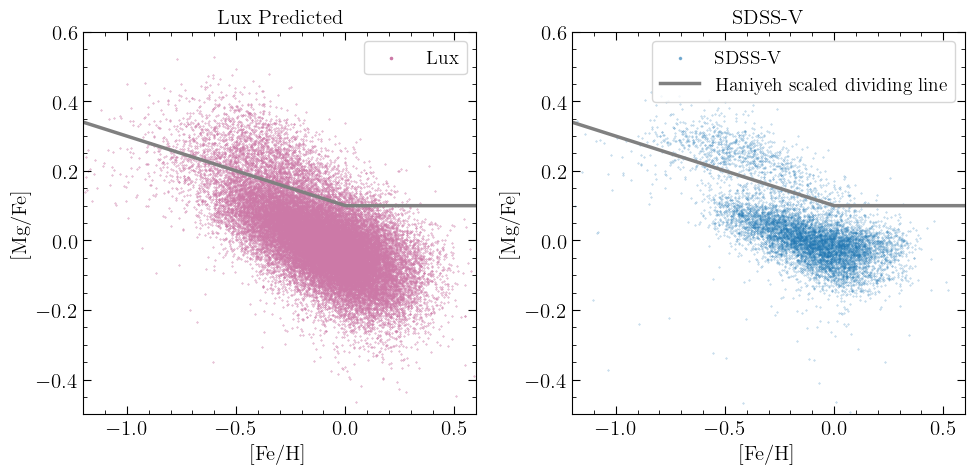

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Simplified broken line generation
# np.interp automatically flatlines outside the provided anchor points [-0.5, 0.2]
fe_h = np.linspace(-1.2, 0.6, 500)
mg_fe = np.where(fe_h > 0, 0.10, 0.10 - 0.2 * fe_h)

# 2. Colors setup
giants_color_sdss = 'tab:blue'
dwarfs_color_sdss = 'tab:orange'
giants_color_lux = '#009E73'  # Bluish Green
dwarfs_color_lux = '#CC79A7'  # Reddish Purple

# 3. Plotting
plt.figure(figsize=(10, 5))

# Subplot 1: Lux
plt.subplot(1, 2, 1)
plt.scatter(lux_pred_all['fe_h'], lux_pred_all['mg_fe'], s=0.1, label='Lux', color=dwarfs_color_lux)
plt.plot(fe_h, mg_fe, color='gray', linewidth=2.5)
plt.legend(markerscale=5)
plt.xlim(-1.2, 0.6)
plt.ylim(-0.5, 0.6)
plt.xlabel('[Fe/H]')
plt.ylabel(r'[Mg/Fe]')
plt.title("Lux Predicted")

# Subplot 2: SDSS-V
plt.subplot(1, 2, 2)
plt.scatter(training_sdss_all['fe_h'], training_sdss_all['mg_fe'], s=0.1, label='SDSS-V', alpha=0.5, color=giants_color_sdss)
plt.plot(fe_h, mg_fe, color='gray', linewidth=2.5, label='Haniyeh scaled dividing line')
plt.legend(markerscale=5)
plt.xlim(-1.2, 0.6)
plt.ylim(-0.5, 0.6)
plt.xlabel('[Fe/H]')
plt.ylabel(r'[Mg/Fe]')
plt.title("SDSS-V")

plt.tight_layout()
plt.show()

# KDE plots

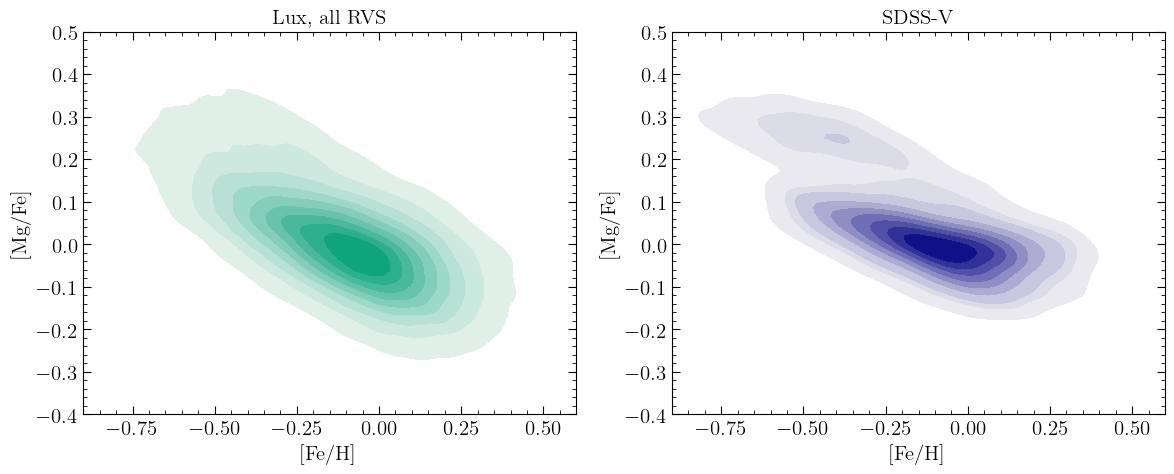

In [36]:
import seaborn as sns

color_sdss = 'navy'
color_lux = '#009E73'  # Bluish Green

# Create custom colormaps based on your colors
cmap_lux = sns.light_palette(color_lux, as_cmap=True)
cmap_sdss = sns.light_palette(color_sdss, as_cmap=True)

# Set up the figure and axes
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: Lux
sns.kdeplot(
    x=lux_pred_all['fe_h'], y=lux_pred_all['mg_fe'], 
    fill=True, cmap=cmap_lux, label='Lux', ax=axes[0]
)

axes[0].set_xlim(-0.9, 0.6)
axes[0].set_ylim(-0.4, 0.5)
axes[0].set_xlabel('[Fe/H]')
axes[0].set_ylabel('[Mg/Fe]')
axes[0].set_title("Lux, all RVS")


# Subplot 2: SDSS-V
sns.kdeplot(
    x=training_sdss_all['fe_h'], y=training_sdss_all['mg_fe'], 
    fill=True, cmap=cmap_sdss, label='SDSS-V', ax=axes[1]
)

axes[1].set_xlim(-0.9, 0.6)
axes[1].set_ylim(-0.4, 0.5)
axes[1].set_xlabel('[Fe/H]')
axes[1].set_ylabel('[Mg/Fe]')
axes[1].set_title("SDSS-V")

plt.tight_layout()
plt.show()

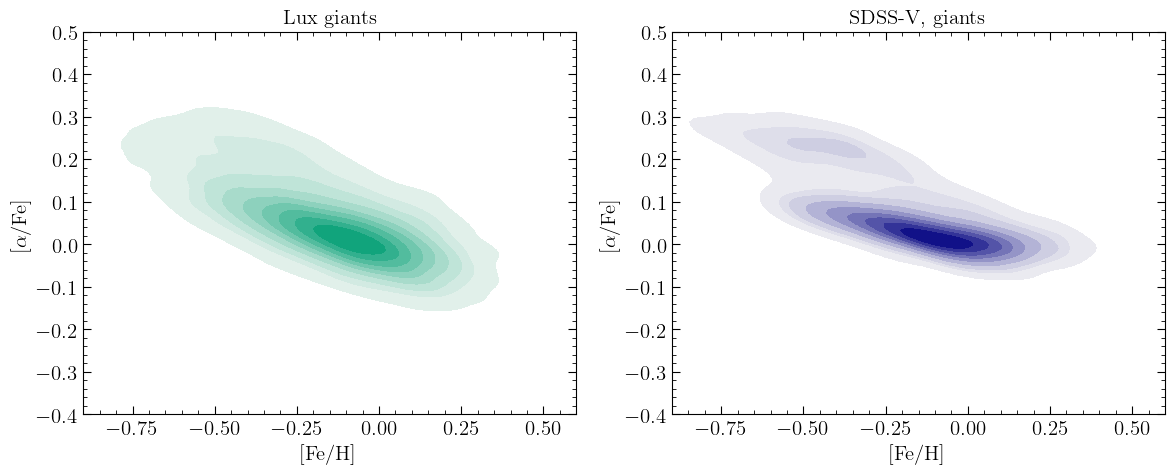

In [37]:
color_sdss = 'navy'
color_lux = '#009E73'  # Bluish Green

# Create custom colormaps based on your colors
cmap_lux = sns.light_palette(color_lux, as_cmap=True)
cmap_sdss = sns.light_palette(color_sdss, as_cmap=True)

# Set up the figure and axes
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: Lux
sns.kdeplot(
    x=lux_pred_giants['fe_h'], y=lux_pred_giants['alpha_fe'], 
    fill=True, cmap=cmap_lux, label='Lux', ax=axes[0]
)

axes[0].set_xlim(-0.9, 0.6)
axes[0].set_ylim(-0.4, 0.5)
axes[0].set_xlabel('[Fe/H]')
axes[0].set_ylabel(r'[$\alpha$/Fe]')
axes[0].set_title("Lux giants")


# Subplot 2: SDSS-V
sns.kdeplot(
    x=training_giants_sdss['fe_h'], y=training_giants_sdss['alpha_fe'], 
    fill=True, cmap=cmap_sdss, label='SDSS-V', ax=axes[1]
)

axes[1].set_xlim(-0.9, 0.6)
axes[1].set_ylim(-0.4, 0.5)
axes[1].set_xlabel('[Fe/H]')
axes[1].set_ylabel(r'[$\alpha$/Fe]')
axes[1].set_title("SDSS-V, giants")


plt.tight_layout()
plt.show()

(-0.4, 0.5)

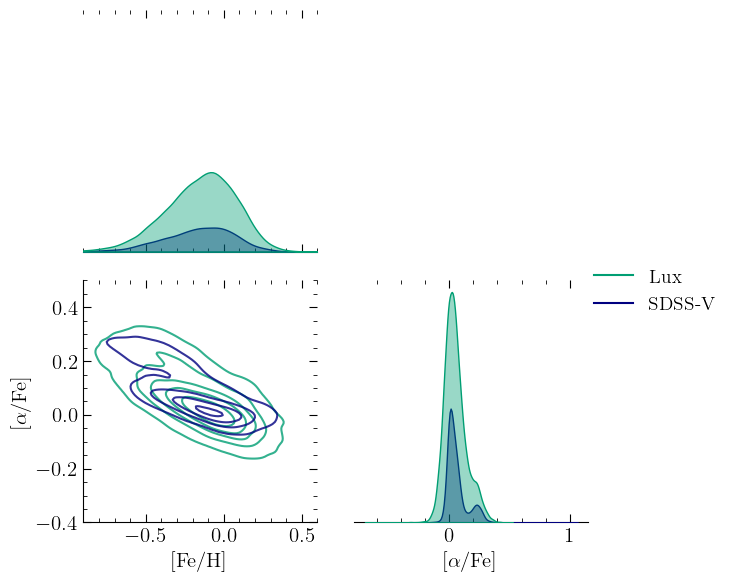

In [38]:
# 1. Combine the data into a single DataFrame
df_lux = lux_pred_giants[['fe_h', 'alpha_fe']].copy()
df_lux['Catalog'] = 'Lux'

df_sdss = training_giants_sdss[['fe_h', 'alpha_fe']].copy()
df_sdss['Catalog'] = 'SDSS-V'

combined_df = pd.concat([df_lux, df_sdss], ignore_index=True)

# 2. Set up the corner plot
g = sns.PairGrid(
    combined_df, 
    hue="Catalog", 
    palette={'Lux': '#009E73',  # Bluish Green,
            'SDSS-V': 'navy'}, 
    corner=True,
    height=3,
)

# 3. Map the plot types to the grid
# Diagonal: 1D KDEs (fill=True shades under the curve)
g.map_diag(sns.kdeplot, fill=True, alpha=0.4)

# Lower triangle: 2D Contour lines (adjust 'levels' for more/fewer rings)
g.map_lower(sns.kdeplot, levels=6, alpha=0.8)

# 4. Clean up labels and legend
g.add_legend(title="")

# Update the axis labels
g.axes[1, 0].set_xlabel('[Fe/H]')
g.axes[1, 0].set_ylabel(r'[$\alpha$/Fe]')
g.axes[1, 1].set_xlabel(r'[$\alpha$/Fe]')

# Apply your standard limits
g.axes[1, 0].set_xlim(-0.9, 0.6)
g.axes[1, 0].set_ylim(-0.4, 0.5)

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_40600/142200693.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_40600/142200693.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


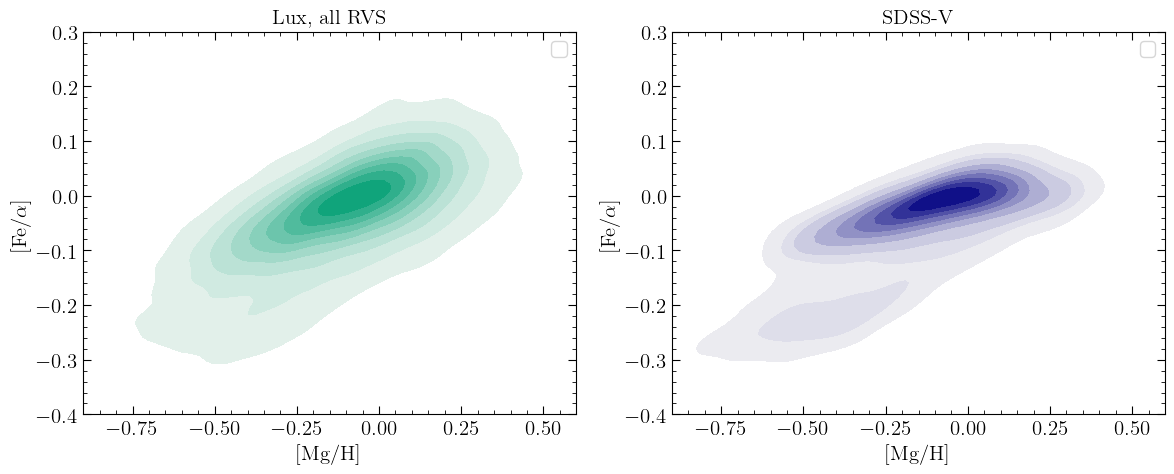

In [39]:
color_sdss = 'navy'
color_lux = '#009E73'  # Bluish Green

# Create custom colormaps based on your colors
cmap_lux = sns.light_palette(color_lux, as_cmap=True)
cmap_sdss = sns.light_palette(color_sdss, as_cmap=True)

# Set up the figure and axes
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: Lux
sns.kdeplot(
    x=lux_pred_all['fe_h'], y=lux_pred_all['fe_alpha'], 
    fill=True, cmap=cmap_lux, label='Lux', ax=axes[0]
)

axes[0].set_ylim(-0.4,0.3)
axes[0].set_xlim(-0.9,0.6)
axes[0].set_xlabel('[Mg/H]')
axes[0].set_ylabel(r'[Fe/$\alpha$]')
axes[0].set_title("Lux, all RVS")
axes[0].legend()

# Subplot 2: SDSS-V
sns.kdeplot(
    x=training_sdss_all['fe_h'], y=training_sdss_all['fe_alpha'], 
    fill=True, cmap=cmap_sdss, label='SDSS-V', ax=axes[1]
)

axes[1].set_ylim(-0.4,0.3)
axes[1].set_xlim(-0.9,0.6)
axes[1].set_xlabel('[Mg/H]')
axes[1].set_ylabel(r'[Fe/$\alpha$]')
axes[1].set_title("SDSS-V")
axes[1].legend()

plt.tight_layout()
plt.show()

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_40600/306900560.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_40600/306900560.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


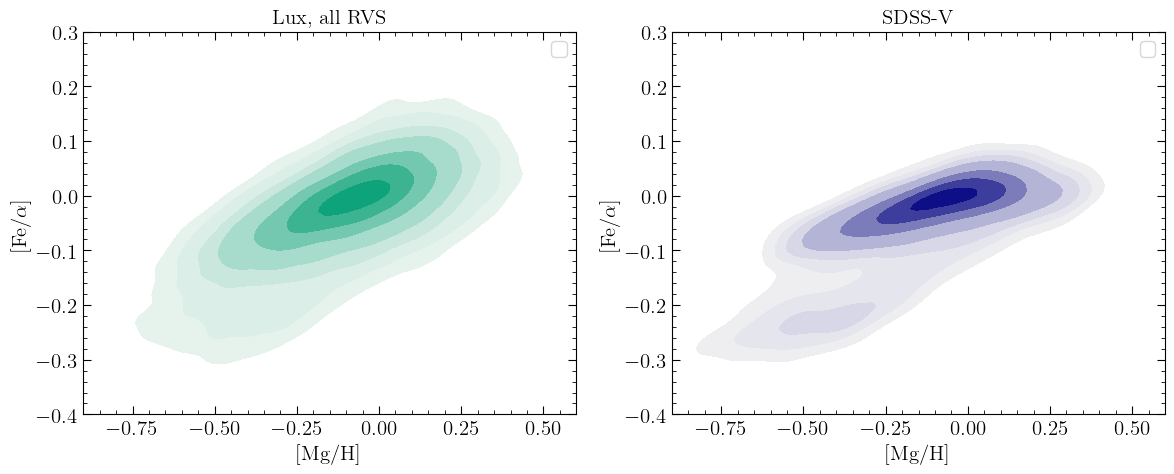

In [40]:
color_sdss = 'navy'
color_lux = '#009E73'  # Bluish Green

# Create custom colormaps based on your colors
cmap_lux = sns.light_palette(color_lux, as_cmap=True)
cmap_sdss = sns.light_palette(color_sdss, as_cmap=True)

# Define the probability mass levels for the contours
mass_levels = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 0.99999]
outer_threshold = 0.05 # Excludes the lowest 5% density

# Set up the figure and axes
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: Lux
sns.kdeplot(
    x=lux_pred_all['fe_h'], y=lux_pred_all['fe_alpha'], 
    fill=True, cmap=cmap_lux, label='Lux', ax=axes[0],
    levels=mass_levels, thresh=outer_threshold
)

axes[0].set_ylim(-0.4, 0.3)
axes[0].set_xlim(-0.9, 0.6)
axes[0].set_xlabel('[Mg/H]')
axes[0].set_ylabel(r'[Fe/$\alpha$]')
axes[0].set_title("Lux, all RVS")
axes[0].legend()

# Subplot 2: SDSS-V
sns.kdeplot(
    x=training_sdss_all['fe_h'], y=training_sdss_all['fe_alpha'], 
    fill=True, cmap=cmap_sdss, label='SDSS-V', ax=axes[1],
    levels=mass_levels, thresh=outer_threshold
)

axes[1].set_ylim(-0.4, 0.3)
axes[1].set_xlim(-0.9, 0.6)
axes[1].set_xlabel('[Mg/H]')
axes[1].set_ylabel(r'[Fe/$\alpha$]')
axes[1].set_title("SDSS-V")
axes[1].legend()

plt.tight_layout()
plt.show()

# Bins of logg and Teff

In [41]:
teff_bins = np.arange(4000, 6000, 500)
logg_bins = np.arange(0, 5, 1)

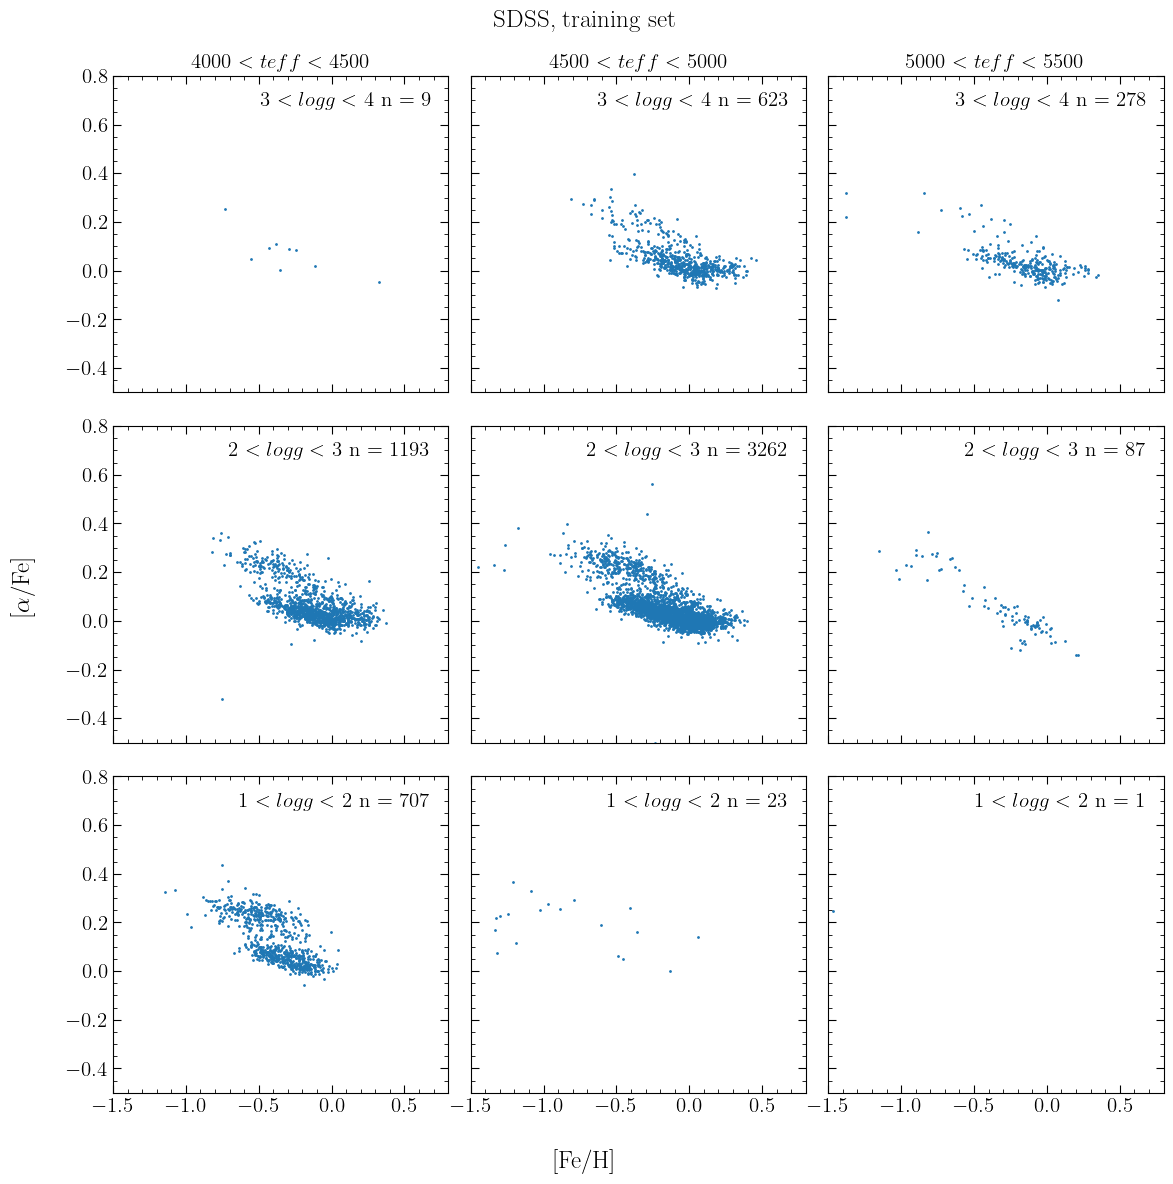

In [42]:
# 1. Define the bins
teff_bins = np.arange(4000, 6000, 500)
logg_bins = np.arange(1, 5, 1)

# FIX: Map rows to logg_bins and columns to teff_bins
n_rows = len(logg_bins) - 1
n_cols = len(teff_bins) - 1

# 2. Set up the matplotlib grid
fig, axes = plt.subplots(
    nrows=n_rows, 
    ncols=n_cols, 
    figsize=(12, 12), 
    sharex=True, 
    sharey=True
)

# 3. Iterate and plot
for i in range(n_rows):
    # Invert row index so Z=0 is at the bottom
    row_idx = n_rows - 1 - i 
    logg_min, logg_max = logg_bins[i], logg_bins[i+1]
    
    for j in range(n_cols):
        teff_min, teff_max = teff_bins[j], teff_bins[j+1]
        ax = axes[row_idx, j]
        
        # Filter the dataset
        mask = (
            (training_sdss_all['teff'] >= teff_min) & 
            (training_sdss_all['teff'] < teff_max) & 
            (training_sdss_all['logg'] >= logg_min) & 
            (training_sdss_all['logg'] < logg_max)
        )
        subset = training_sdss_all[mask]
        
        # Scatter plot for this bin
        ax.scatter(subset['fe_h'], subset['alpha_fe'], s=1, alpha=1, color='tab:blue')
        
        # Format grid titles (teff bins on top row)
        if row_idx == 0:  
            ax.set_title(fr'{teff_min} $ < teff < $ {teff_max}')
            
        # Zmax text inside every plot (like a legend)
        ax.text(0.95, 0.95, fr'{logg_min} $ < logg < $ {logg_max} n = {len(subset)}', 
                transform=ax.transAxes, 
                horizontalalignment='right', 
                verticalalignment='top',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        ax.set_ylim(-0.5, 0.8)
        ax.set_xlim(-1.5, 0.8)

# 4. Add global labels
fig.supxlabel('[Fe/H]')
fig.supylabel(r'[$\alpha$/Fe]')
fig.suptitle("SDSS, training set")
plt.tight_layout()
plt.show()

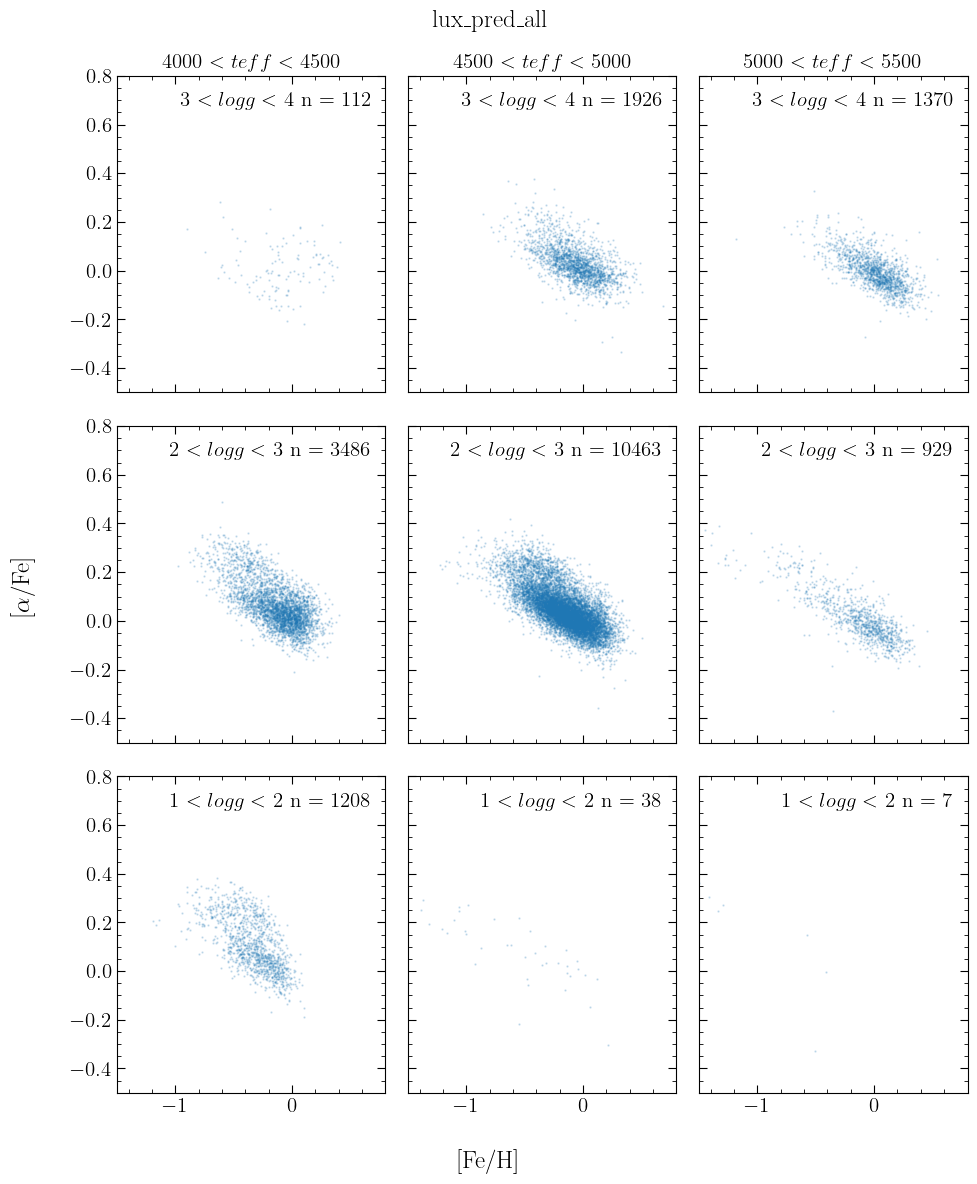

In [43]:
# 1. Define the bins
teff_bins = np.arange(4000, 6000, 500)
logg_bins = np.arange(1, 5, 1)

# FIX: Map rows to logg_bins and columns to teff_bins
n_rows = len(logg_bins) - 1
n_cols = len(teff_bins) - 1

# 2. Set up the matplotlib grid
fig, axes = plt.subplots(
    nrows=n_rows, 
    ncols=n_cols, 
    figsize=(10, 12), 
    sharex=True, 
    sharey=True
)

# 3. Iterate and plot
for i in range(n_rows):
    # Invert row index so Z=0 is at the bottom
    row_idx = n_rows - 1 - i 
    logg_min, logg_max = logg_bins[i], logg_bins[i+1]
    
    for j in range(n_cols):
        teff_min, teff_max = teff_bins[j], teff_bins[j+1]
        ax = axes[row_idx, j]
        
        # Filter the dataset
        mask = (
            (lux_pred_all['teff'] >= teff_min) & 
            (lux_pred_all['teff'] < teff_max) & 
            (lux_pred_all['logg'] >= logg_min) & 
            (lux_pred_all['logg'] < logg_max)
        )
        subset = lux_pred_all[mask]
        
        # Scatter plot for this bin
        ax.scatter(subset['fe_h'], subset['alpha_fe'], s=0.5, alpha=0.2, color='tab:blue')
        
        # Format grid titles (teff bins on top row)
        if row_idx == 0:  
            ax.set_title(fr'{teff_min} $ < teff < $ {teff_max}')
            
        # Zmax text inside every plot (like a legend)
        ax.text(0.95, 0.95, fr'{logg_min} $ < logg < $ {logg_max} n = {len(subset)}', 
                transform=ax.transAxes, 
                horizontalalignment='right', 
                verticalalignment='top',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        ax.set_ylim(-0.5, 0.8)
        ax.set_xlim(-1.5, 0.8)

# 4. Add global labels
fig.supxlabel('[Fe/H]')
fig.supylabel(r'[$\alpha$/Fe]')
fig.suptitle("lux_pred_all")
plt.tight_layout()
plt.show()

Text(0, 0.5, 'logg')

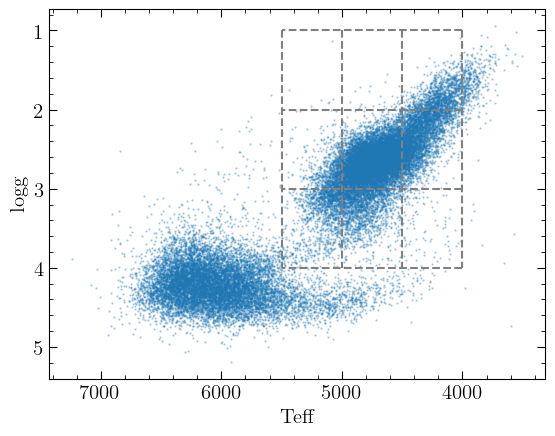

In [44]:
plt.scatter(lux_pred_all['teff'], lux_pred_all['logg'], s=0.5, alpha=0.3)
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

for i in range(len(logg_bins)):
    plt.plot([teff_bins[0], teff_bins[-1]], [logg_bins[i], logg_bins[i]], linestyle = '--', color = 'gray')

for i in range(len(teff_bins)):
    plt.plot([teff_bins[i], teff_bins[i]], [logg_bins[0], logg_bins[-1]], linestyle = '--', color = 'gray')


plt.xlabel("Teff")
plt.ylabel("logg")

In [45]:
teff_bins[0]

np.int64(4000)

In [46]:
teff_bins[-1]

np.int64(5500)

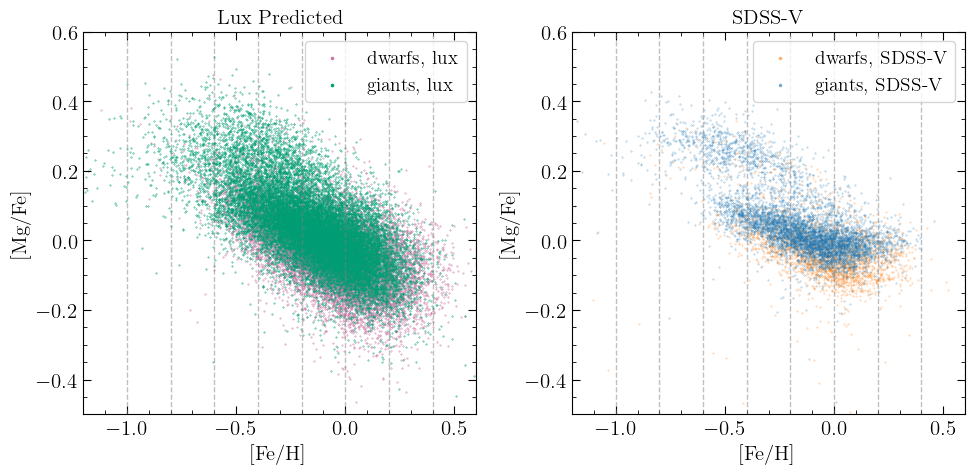

In [47]:
import numpy as np

giants_color_sdss = 'tab:blue'
dwarfs_color_sdss = 'tab:orange'

giants_color_lux = '#009E73'  # Bluish Green
dwarfs_color_lux = '#CC79A7'  # Reddish Purple

# Define bin edges starting from -1.0, stepping by 0.2, up to 0.6 (to cover the 0.5 mark)
bin_edges = np.arange(-1.0, 0.7, 0.2)

plt.figure(figsize=(10,5))

# Subplot 1: Lux Predicted
plt.subplot(1,2,1)
plt.scatter(lux_pred_dwarfs['fe_h'], lux_pred_dwarfs['mg_fe'], s = 0.1, label = 'dwarfs, lux', color = dwarfs_color_lux)
plt.scatter(lux_pred_giants['fe_h'], lux_pred_giants['mg_fe'], s = 0.1, label = 'giants, lux', color = giants_color_lux)
plt.legend(markerscale=5)
plt.xlim(-1.2, 0.6)
plt.ylim(-0.5, 0.6)
plt.xlabel('[Fe/H]')
plt.ylabel('[Mg/Fe]')
plt.title("Lux Predicted")

# Draw vertical lines for bins
for edge in bin_edges:
    plt.axvline(x=edge, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Subplot 2: SDSS-V
plt.subplot(1,2,2)
plt.scatter(training_dwarfs_sdss['fe_h'], training_dwarfs_sdss['mg_fe'], s = 0.1, label = 'dwarfs, SDSS-V', alpha = 0.5, color = dwarfs_color_sdss)
plt.scatter(training_giants_sdss['fe_h'], training_giants_sdss['mg_fe'], s = 0.1, label = 'giants, SDSS-V', alpha = 0.5, color = giants_color_sdss)
plt.legend(markerscale=5)
plt.xlim(-1.2, 0.6)
plt.ylim(-0.5, 0.6)
plt.xlabel('[Fe/H]')
plt.ylabel('[Mg/Fe]')
plt.title("SDSS-V")

# Draw vertical lines for bins
for edge in bin_edges:
    plt.axvline(x=edge, color='gray', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.show()

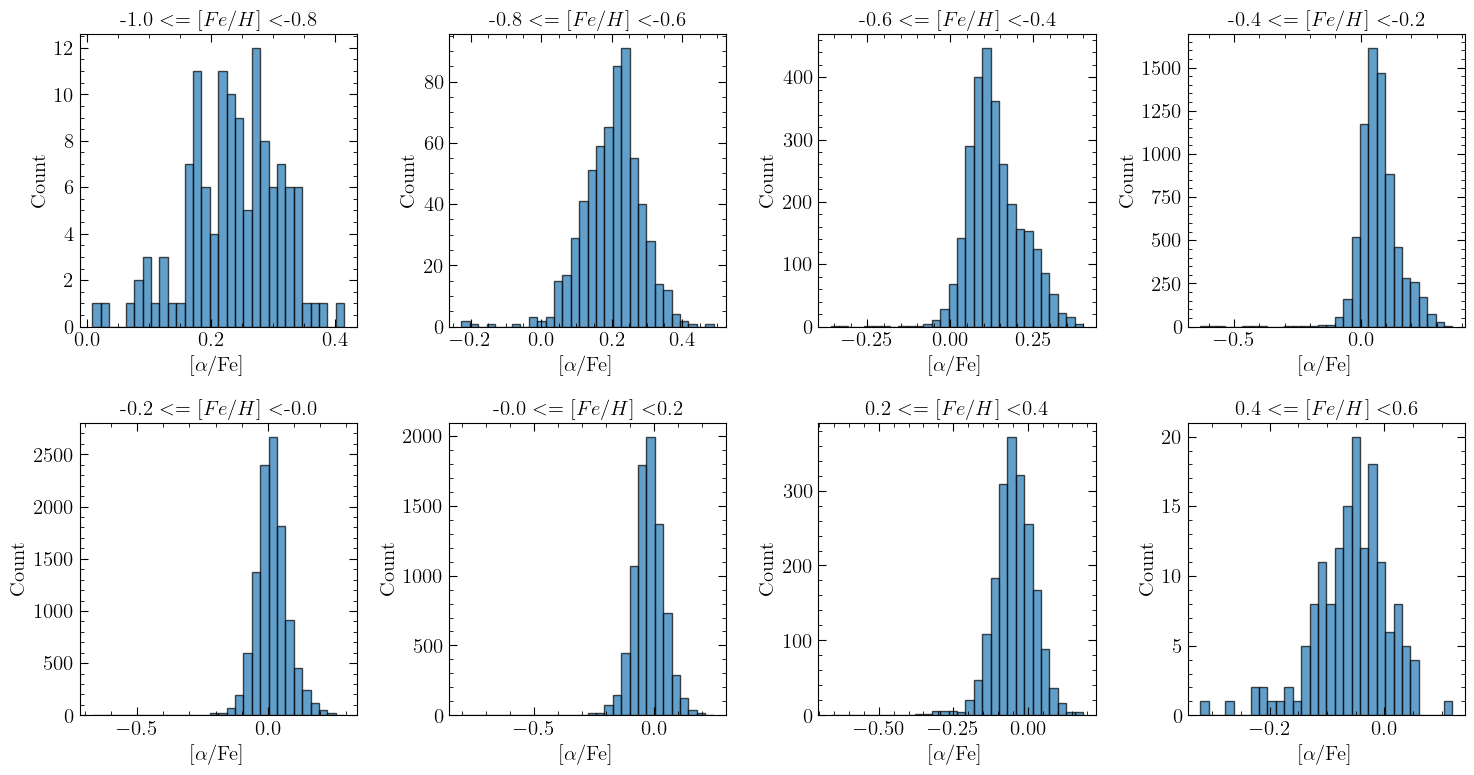

In [52]:
# Define the bin edges
bin_edges = np.arange(-1.0, 0.7, 0.2)
n_bins = len(bin_edges) - 1

# Set up a grid for the subplots (e.g., 4 columns)
n_cols = 4
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

# Loop through all created axes
for i in range(len(axes)):
        bin_start = bin_edges[i]
        bin_end = bin_edges[i+1]
        
        # Filter data for the current [Fe/H] bin
        mask = (lux_pred_all['fe_h'] >= bin_start) & (lux_pred_all['fe_h'] < bin_end)
        bin_data = lux_pred_all[mask]
        
        # Plot the histogram
        axes[i].hist(bin_data['alpha_fe'], bins=30, color='tab:blue', edgecolor='black', alpha=0.7)
        
        # Add labels and title showing the bin range
        axes[i].set_title(fr"{bin_start:.1f} $ <= [Fe/H] < ${bin_end:.1f}")
        axes[i].set_xlabel(r'[$\alpha$/Fe]')
        axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

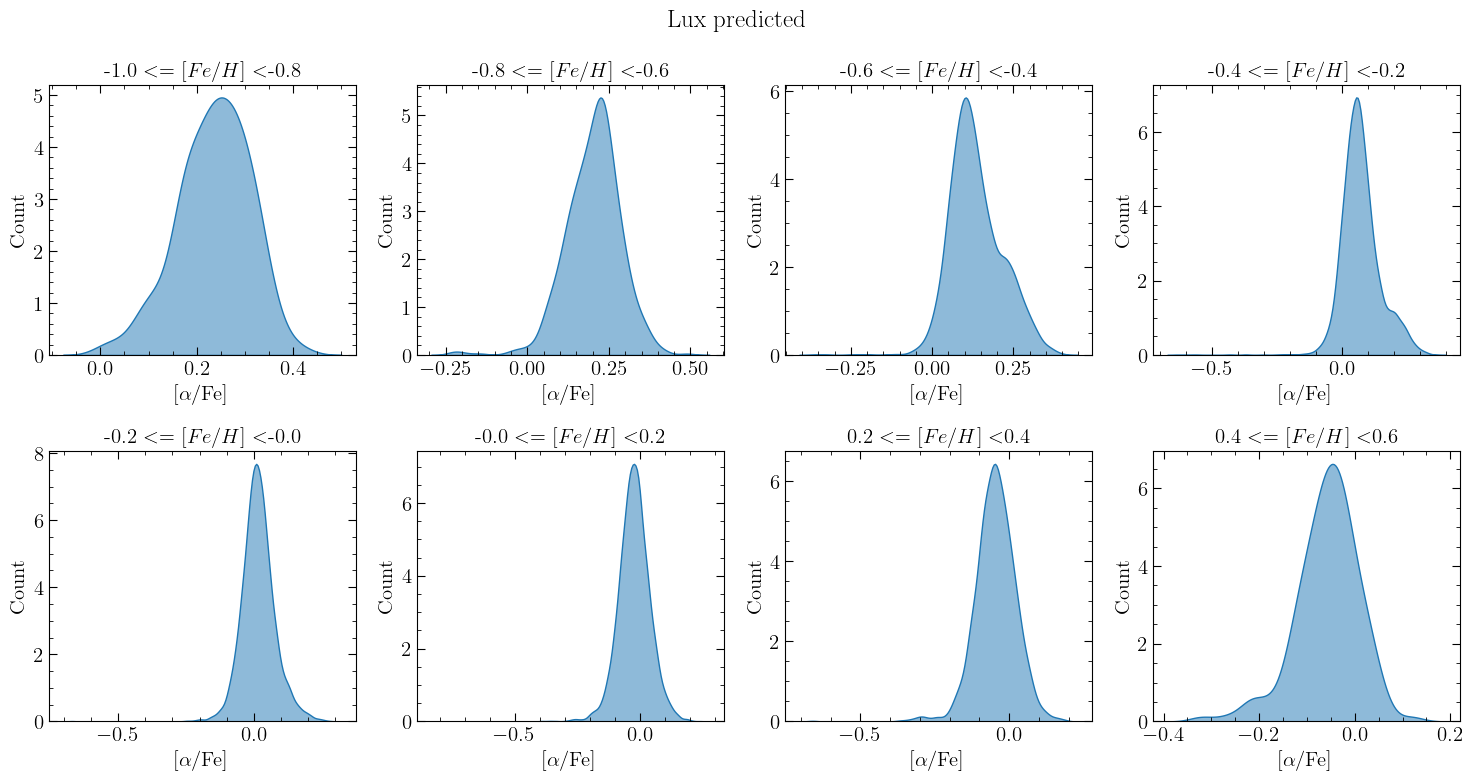

In [54]:
# Define the bin edges
bin_edges = np.arange(-1.0, 0.7, 0.2)
n_bins = len(bin_edges) - 1

# Set up a grid for the subplots (e.g., 4 columns)
n_cols = 4
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

# Loop through all created axes
for i in range(len(axes)):
        bin_start = bin_edges[i]
        bin_end = bin_edges[i+1]
        
        # Filter data for the current [Fe/H] bin
        mask = (lux_pred_all['fe_h'] >= bin_start) & (lux_pred_all['fe_h'] < bin_end)
        bin_data = lux_pred_all[mask]
        
        # Plot the histogram
        sns.kdeplot(data=bin_data, x='alpha_fe', ax=axes[i], fill=True, color='tab:blue', alpha=0.5)
        
        # Add labels and title showing the bin range
        axes[i].set_title(fr"{bin_start:.1f} $ <= [Fe/H] < ${bin_end:.1f}")
        axes[i].set_xlabel(r'[$\alpha$/Fe]')
        axes[i].set_ylabel('Count')

plt.suptitle("Lux predicted")
plt.tight_layout()
plt.show()

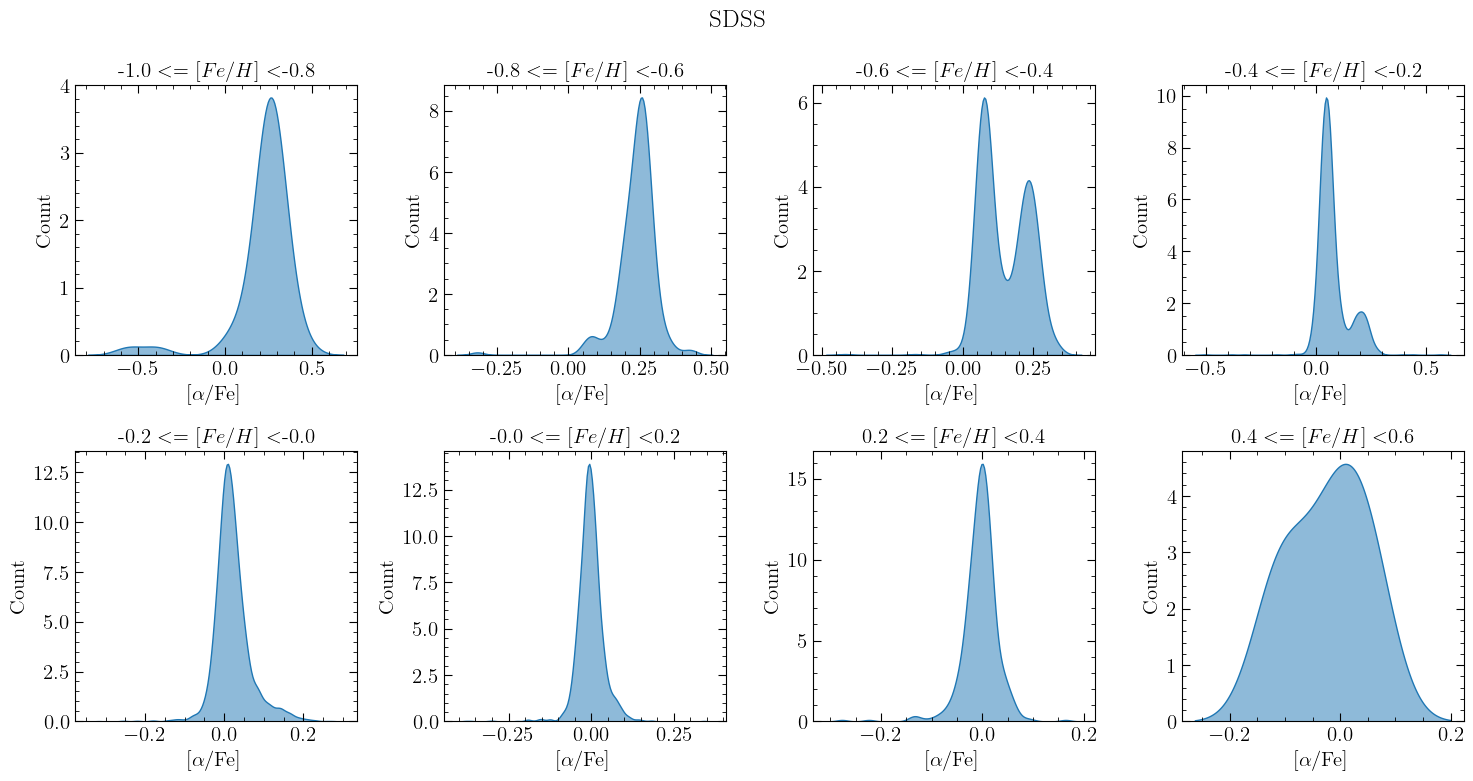

In [55]:
# Define the bin edges
bin_edges = np.arange(-1.0, 0.7, 0.2)
n_bins = len(bin_edges) - 1

# Set up a grid for the subplots (e.g., 4 columns)
n_cols = 4
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

# Loop through all created axes
for i in range(len(axes)):
        bin_start = bin_edges[i]
        bin_end = bin_edges[i+1]
        
        # Filter data for the current [Fe/H] bin
        mask = (training_sdss_all['fe_h'] >= bin_start) & (training_sdss_all['fe_h'] < bin_end)
        bin_data = training_sdss_all[mask]
        
        # Plot the histogram
        sns.kdeplot(data=bin_data, x='alpha_fe', ax=axes[i], fill=True, color='tab:blue', alpha=0.5)
        
        # Add labels and title showing the bin range
        axes[i].set_title(fr"{bin_start:.1f} $ <= [Fe/H] < ${bin_end:.1f}")
        axes[i].set_xlabel(r'[$\alpha$/Fe]')
        axes[i].set_ylabel('Count')

plt.suptitle("SDSS")
plt.tight_layout()
plt.show()

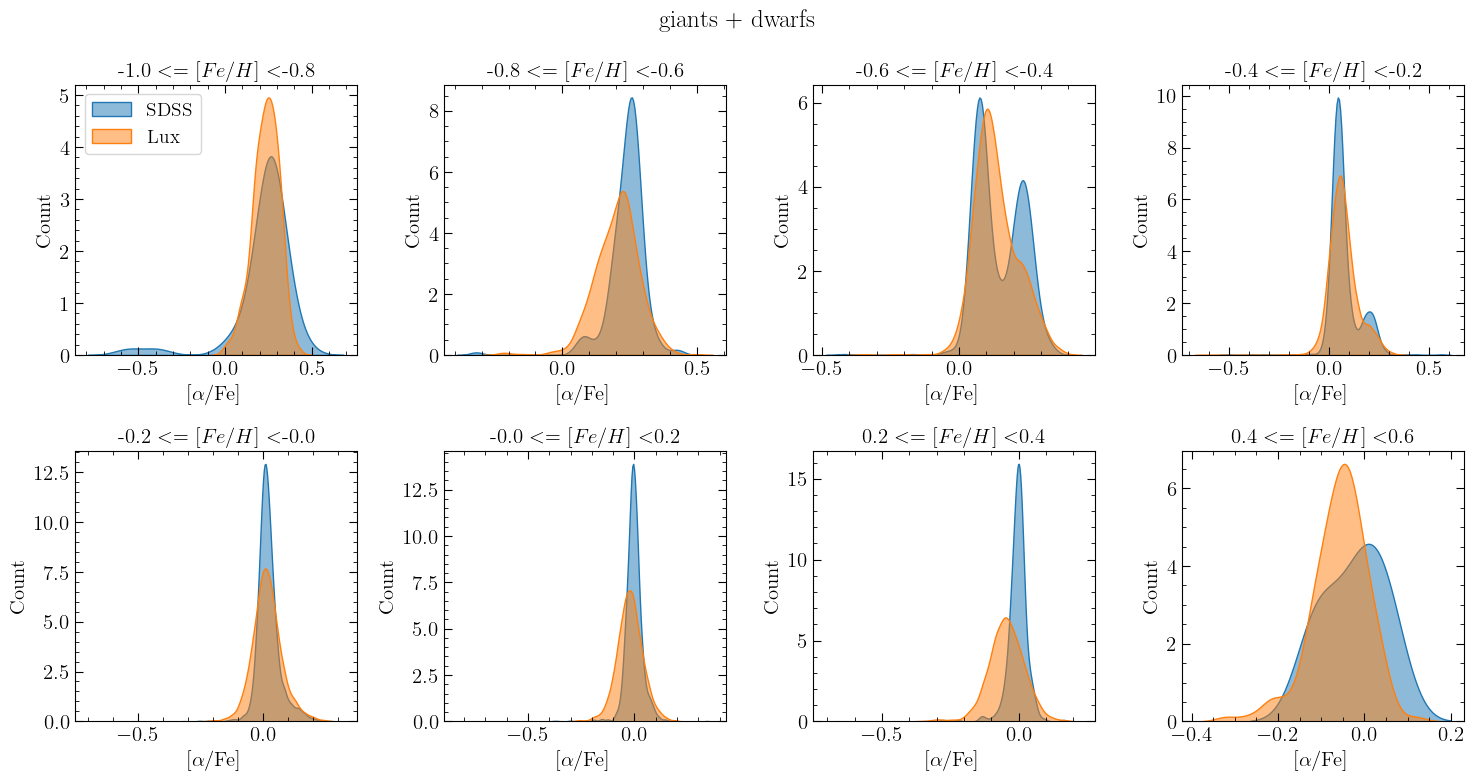

In [75]:
# Define the bin edges
bin_edges = np.arange(-1.0, 0.7, 0.2)
n_bins = len(bin_edges) - 1

# Set up a grid for the subplots (e.g., 4 columns)
n_cols = 4
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

# Loop through all created axes
for i in range(len(axes)):
        bin_start = bin_edges[i]
        bin_end = bin_edges[i+1]
        
        bin_data_sdss = training_sdss_all[(training_sdss_all['fe_h'] >= bin_start) & (training_sdss_all['fe_h'] < bin_end)]
        bin_data_lux = lux_pred_all[(lux_pred_all['fe_h'] >= bin_start) & (lux_pred_all['fe_h'] < bin_end)]
        
        # Plot the histogram
        sns.kdeplot(data=bin_data_sdss, x='alpha_fe', ax=axes[i], fill=True, color='tab:blue', alpha=0.5, label = 'SDSS')
        sns.kdeplot(data=bin_data_lux, x='alpha_fe', ax=axes[i], fill=True, color='tab:orange', alpha=0.5, label = 'Lux')
        
        # Add labels and title showing the bin range
        axes[i].set_title(fr"{bin_start:.1f} $ <= [Fe/H] < ${bin_end:.1f}")
        axes[i].set_xlabel(r'[$\alpha$/Fe]')
        axes[i].set_ylabel('Count')

axes[0].legend()
plt.suptitle("giants + dwarfs")
plt.tight_layout()
plt.show()

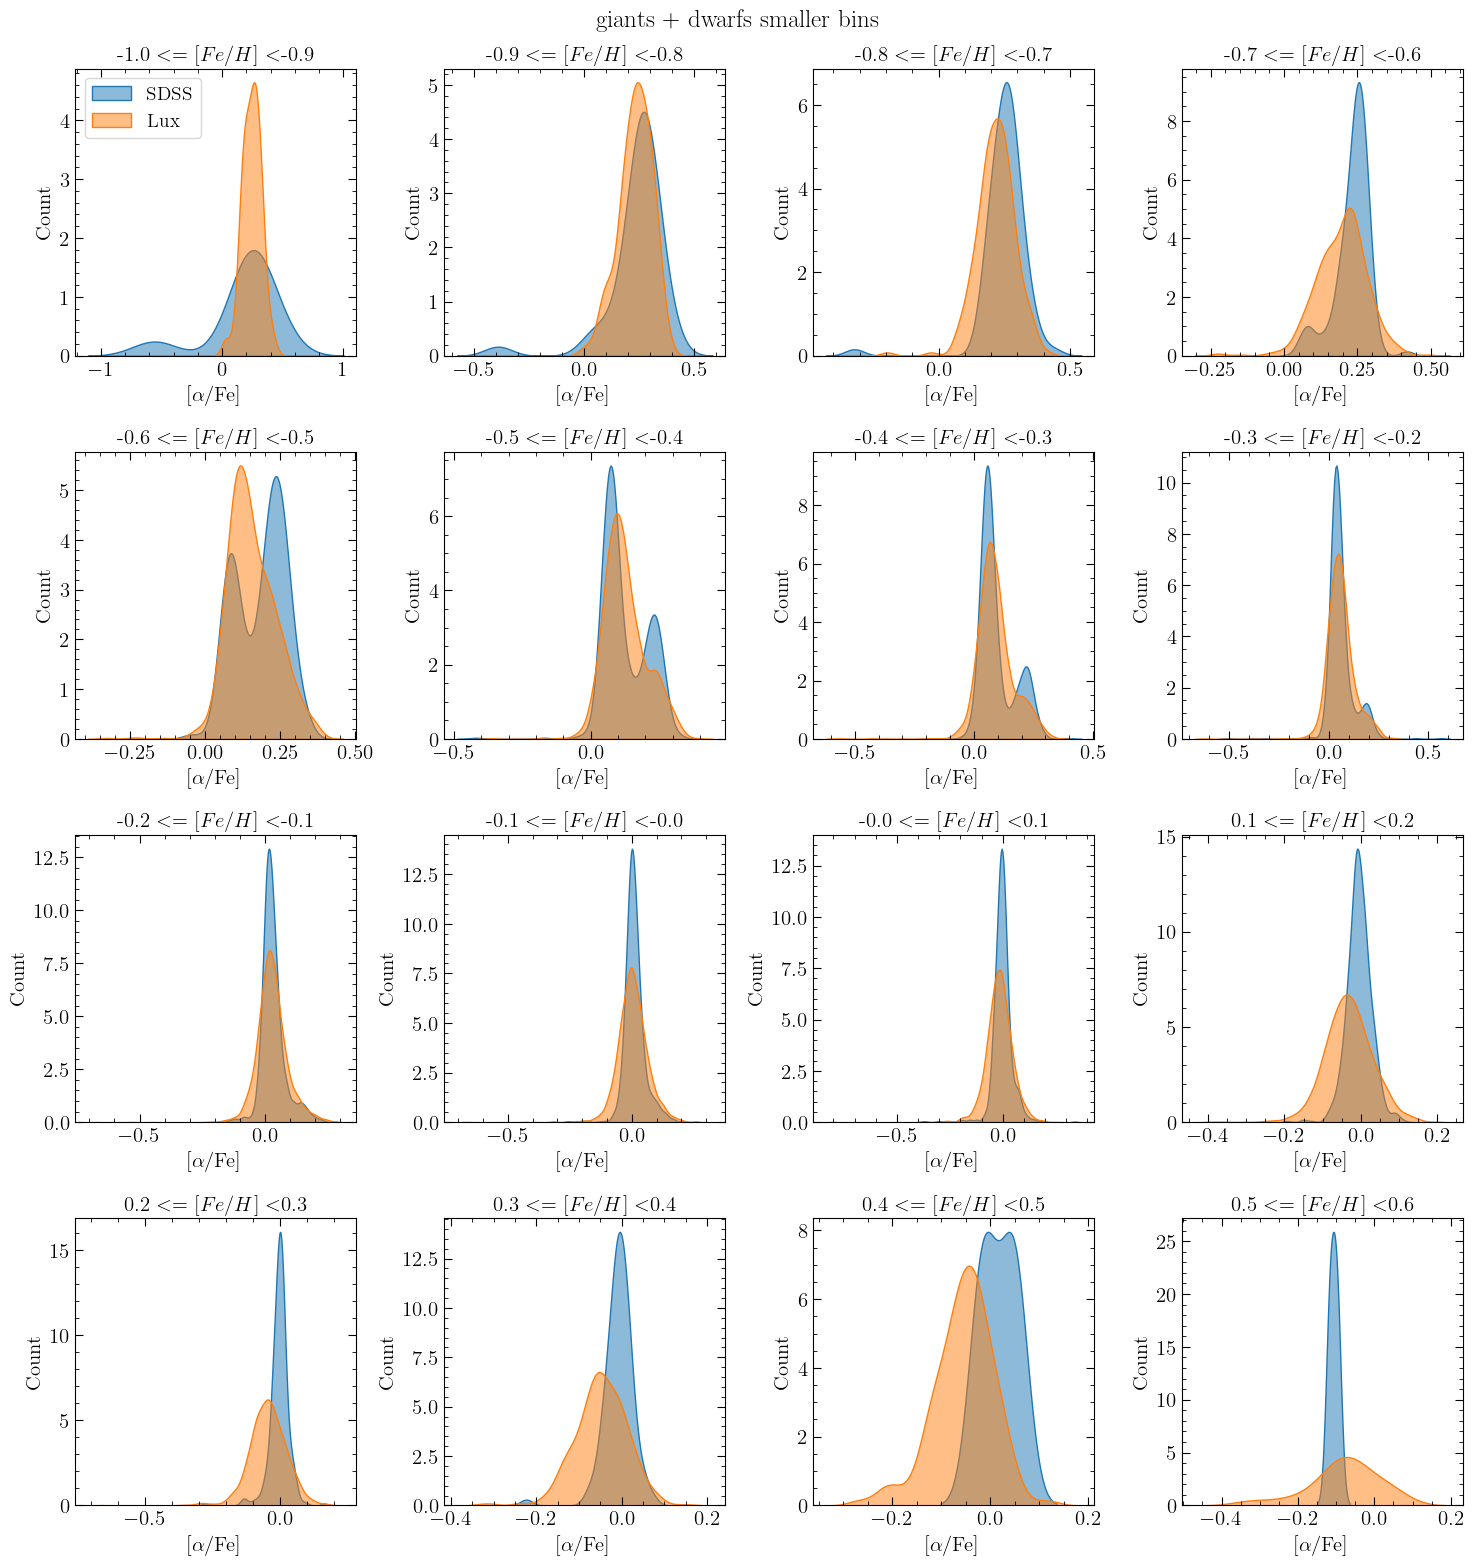

In [76]:
# Define the bin edges
bin_edges = np.arange(-1.0, 0.7, 0.1)
n_bins = len(bin_edges) - 1

# Set up a grid for the subplots (e.g., 4 columns)
n_cols = 4
n_rows = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

# Loop through all created axes
for i in range(len(axes)):
        bin_start = bin_edges[i]
        bin_end = bin_edges[i+1]
        
        bin_data_sdss = training_sdss_all[(training_sdss_all['fe_h'] >= bin_start) & (training_sdss_all['fe_h'] < bin_end)]
        bin_data_lux = lux_pred_all[(lux_pred_all['fe_h'] >= bin_start) & (lux_pred_all['fe_h'] < bin_end)]
        
        # Plot the histogram
        sns.kdeplot(data=bin_data_sdss, x='alpha_fe', ax=axes[i], fill=True, color='tab:blue', alpha=0.5, label = 'SDSS')
        sns.kdeplot(data=bin_data_lux, x='alpha_fe', ax=axes[i], fill=True, color='tab:orange', alpha=0.5, label = 'Lux')
        
        # Add labels and title showing the bin range
        axes[i].set_title(fr"{bin_start:.1f} $ <= [Fe/H] < ${bin_end:.1f}")
        axes[i].set_xlabel(r'[$\alpha$/Fe]')
        axes[i].set_ylabel('Count')

plt.suptitle("giants + dwarfs smaller bins")
axes[0].legend()
plt.tight_layout()
plt.show()

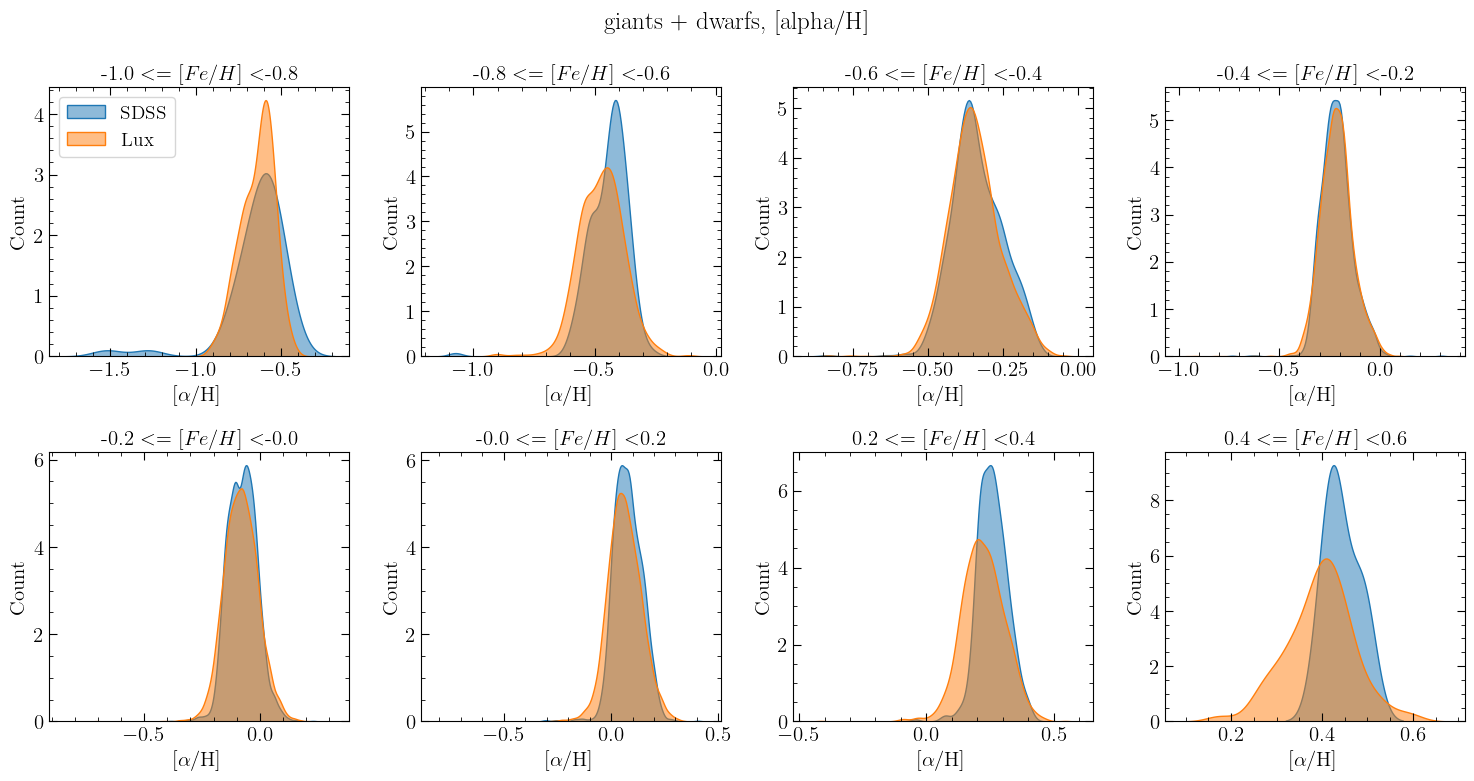

In [77]:
# Define the bin edges
bin_edges = np.arange(-1.0, 0.7, 0.2)
n_bins = len(bin_edges) - 1

# Set up a grid for the subplots (e.g., 4 columns)
n_cols = 4
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

# Loop through all created axes
for i in range(len(axes)):
        bin_start = bin_edges[i]
        bin_end = bin_edges[i+1]
        
        bin_data_sdss = training_sdss_all[(training_sdss_all['fe_h'] >= bin_start) & (training_sdss_all['fe_h'] < bin_end)]
        bin_data_lux = lux_pred_all[(lux_pred_all['fe_h'] >= bin_start) & (lux_pred_all['fe_h'] < bin_end)]
        
        # Plot the histogram
        sns.kdeplot(data=bin_data_sdss, x='alpha_h', ax=axes[i], fill=True, color='tab:blue', alpha=0.5, label = 'SDSS')
        sns.kdeplot(data=bin_data_lux, x='alpha_h', ax=axes[i], fill=True, color='tab:orange', alpha=0.5, label = 'Lux')
        
        # Add labels and title showing the bin range
        axes[i].set_title(fr"{bin_start:.1f} $ <= [Fe/H] < ${bin_end:.1f}")
        axes[i].set_xlabel(r'[$\alpha$/H]')
        axes[i].set_ylabel('Count')

plt.suptitle("giants + dwarfs, [alpha/H]")
axes[0].legend()
plt.tight_layout()
plt.show()

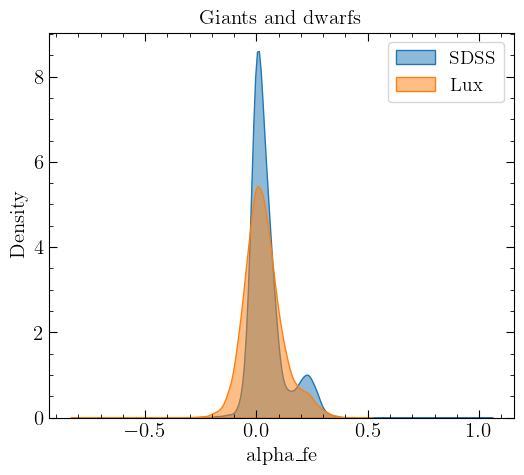

In [73]:
plt.figure(figsize=(6,5))

sns.kdeplot(training_sdss_all, x='alpha_fe', fill=True, color='tab:blue', alpha=0.5, label = 'SDSS')
sns.kdeplot(lux_pred_all, x='alpha_fe', fill=True, color='tab:orange', alpha=0.5, label = 'Lux')

plt.title("Giants and dwarfs")
plt.legend()
plt.show()

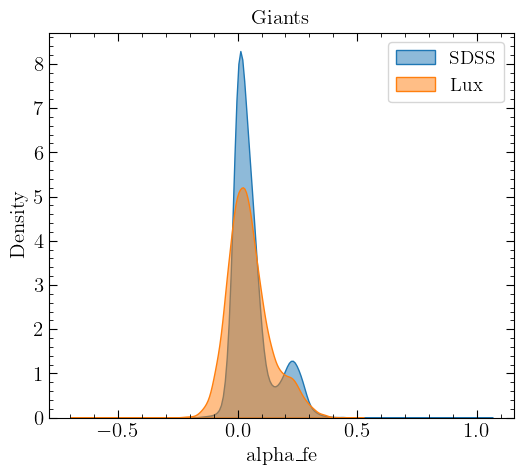

In [72]:
plt.figure(figsize=(6,5))

sns.kdeplot(training_giants_sdss, x='alpha_fe', fill=True, color='tab:blue', alpha=0.5, label = 'SDSS')
sns.kdeplot(lux_pred_giants, x='alpha_fe', fill=True, color='tab:orange', alpha=0.5, label = 'Lux')

plt.title("Giants")
plt.legend()
plt.show()

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_40600/3599580812.py:21: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=bin_data_sdss, x='alpha_fe', ax=axes[i], fill=True, color='tab:blue', alpha=0.5, label = 'SDSS')


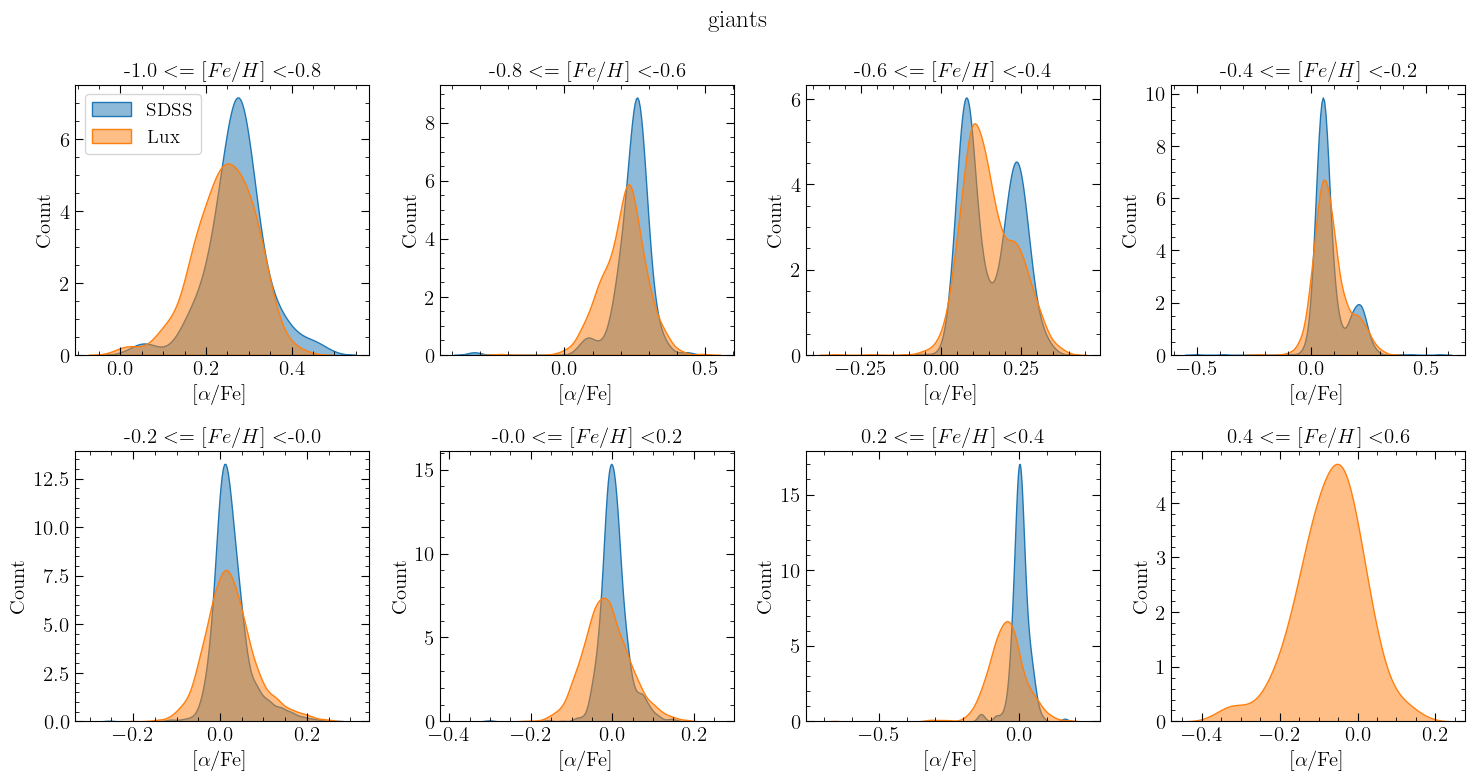

In [74]:
# Define the bin edges
bin_edges = np.arange(-1.0, 0.7, 0.2)
n_bins = len(bin_edges) - 1

# Set up a grid for the subplots (e.g., 4 columns)
n_cols = 4
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

# Loop through all created axes
for i in range(len(axes)):
        bin_start = bin_edges[i]
        bin_end = bin_edges[i+1]
        
        bin_data_sdss = training_giants_sdss[(training_giants_sdss['fe_h'] >= bin_start) & (training_giants_sdss['fe_h'] < bin_end)]
        bin_data_lux = lux_pred_giants[(lux_pred_giants['fe_h'] >= bin_start) & (lux_pred_giants['fe_h'] < bin_end)]
        
        # Plot the histogram
        sns.kdeplot(data=bin_data_sdss, x='alpha_fe', ax=axes[i], fill=True, color='tab:blue', alpha=0.5, label = 'SDSS')
        sns.kdeplot(data=bin_data_lux, x='alpha_fe', ax=axes[i], fill=True, color='tab:orange', alpha=0.5, label = 'Lux')
        
        # Add labels and title showing the bin range
        axes[i].set_title(fr"{bin_start:.1f} $ <= [Fe/H] < ${bin_end:.1f}")
        axes[i].set_xlabel(r'[$\alpha$/Fe]')
        axes[i].set_ylabel('Count')

axes[0].legend()
plt.suptitle("giants")
plt.tight_layout()
plt.show()